In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

orders     = pd.read_csv("olist_orders_dataset.csv")
customers  = pd.read_csv("olist_customers_dataset.csv")
items      = pd.read_csv("olist_order_items_dataset.csv")
payments   = pd.read_csv("olist_order_payments_dataset.csv")
reviews    = pd.read_csv("olist_order_reviews_dataset.csv")
products   = pd.read_csv("olist_products_dataset.csv")
sellers    = pd.read_csv("olist_sellers_dataset.csv")
geo        = pd.read_csv("olist_geolocation_dataset.csv")
cat  = pd.read_csv("product_category_name_translation.csv")

## 1. Customers

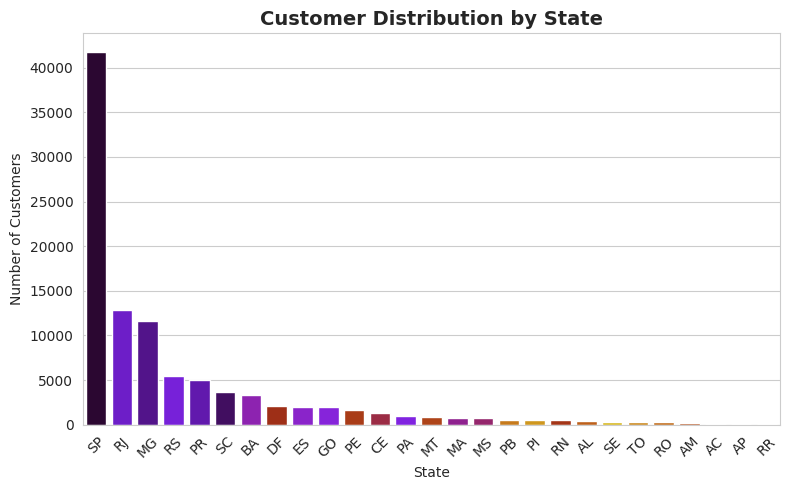

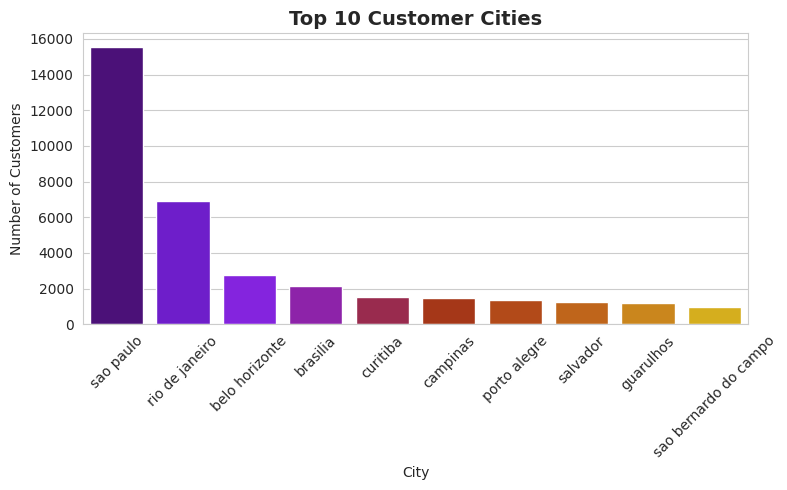

In [5]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8,5)

# -------------------------------
# 1. Customer Distribution by State
# -------------------------------
plt.figure()

sns.countplot(
    x='customer_state',
    data=customers,
    order=customers['customer_state'].value_counts().index,
    hue='customer_state',
    palette='gnuplot',
    legend=False
)

plt.title("Customer Distribution by State", fontsize=14, fontweight='bold')
plt.xlabel("State")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



# -------------------------------
# 2. Top 10 Customer Cities
# -------------------------------
top_cities = customers['customer_city'].value_counts().head(10)

plt.figure()

sns.barplot(
    x=top_cities.index,
    y=top_cities.values,
    hue=top_cities.index,
    palette='gnuplot',
    legend=False
)

plt.title("Top 10 Customer Cities", fontsize=14, fontweight='bold')
plt.xlabel("City")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


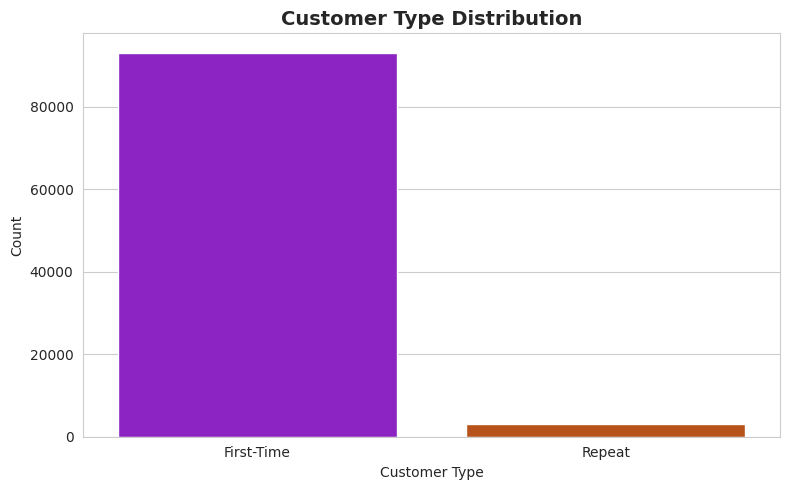

In [6]:
# -------------------------------
# 3. Customer Type (First vs Repeat)
# -------------------------------
customer_counts = customers['customer_unique_id'].value_counts()

customer_type_df = pd.DataFrame({
    'customer_type': ['First-Time', 'Repeat'],
    'count': [
        (customer_counts == 1).sum(),
        (customer_counts > 1).sum()
    ]
})

plt.figure()

sns.barplot(
    x='customer_type',
    y='count',
    data=customer_type_df,
    hue='customer_type',
    palette='gnuplot',
    legend=False
)

plt.title("Customer Type Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Customer Type")
plt.ylabel("Count")

plt.tight_layout()
plt.show()


- Customer Location → Distance → Delivery Delay
- High-density cities → High order volume → Possible delays
- Customer Type → Delivery Experience → Retention

## 2. Geolocation

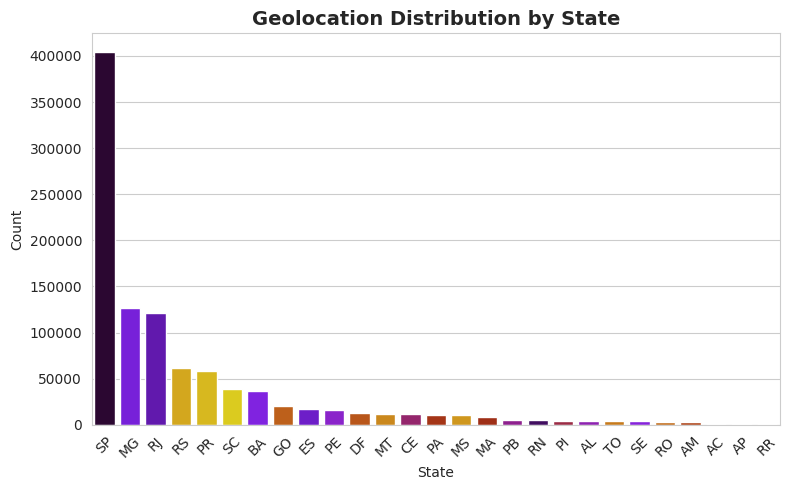

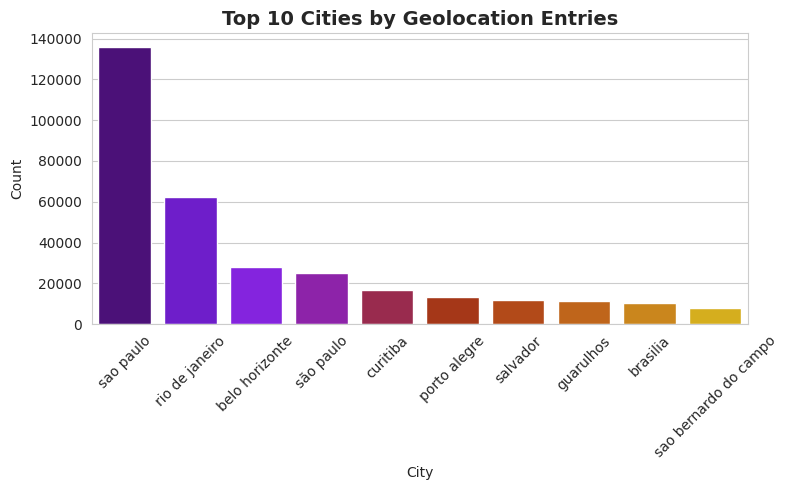

In [7]:

# -------------------------------
# Styling
# -------------------------------
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8,5)

# -------------------------------
# 1. State Distribution
# -------------------------------
plt.figure()

sns.countplot(
    x='geolocation_state',
    data=geo,
    order=geo['geolocation_state'].value_counts().index,
    hue='geolocation_state',
    palette='gnuplot',
    legend=False
)

plt.title("Geolocation Distribution by State", fontsize=14, fontweight='bold')
plt.xlabel("State")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# -------------------------------
# 2. Top 10 Cities
# -------------------------------
top_cities = geo['geolocation_city'].value_counts().head(10)

plt.figure()

sns.barplot(
    x=top_cities.index,
    y=top_cities.values,
    hue=top_cities.index,
    palette='gnuplot',
    legend=False
)

plt.title("Top 10 Cities by Geolocation Entries", fontsize=14, fontweight='bold')
plt.xlabel("City")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




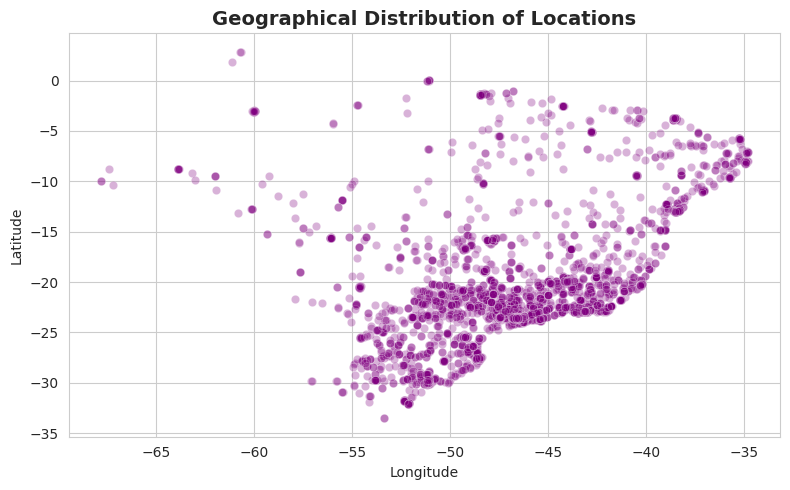

In [8]:
# -------------------------------
# 3. Geographical Scatter (VERY IMPORTANT)
# -------------------------------
plt.figure()

sns.scatterplot(
    x='geolocation_lng',
    y='geolocation_lat',
    data=geo.sample(5000),  # sampling for performance
    alpha=0.3,
    color='purple'
)

plt.title("Geographical Distribution of Locations", fontsize=14, fontweight='bold')
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()
plt.show()



“The geolocation dataset provides critical spatial insights, showing that customer locations are concentrated in major urban regions while also spanning large geographical distances. This variation in distance and regional density plays a key role in delivery delays.”

- Distance (Customer ↔ Seller) ↑ → Delay ↑
- High-density regions → high order volume → delay risk
- Remote locations → logistics difficulty → delay

- distance = customer_location - seller_location
- distance vs is_delayed  🔥 (MOST IMPORTANT FEATURE)

## 3. Items

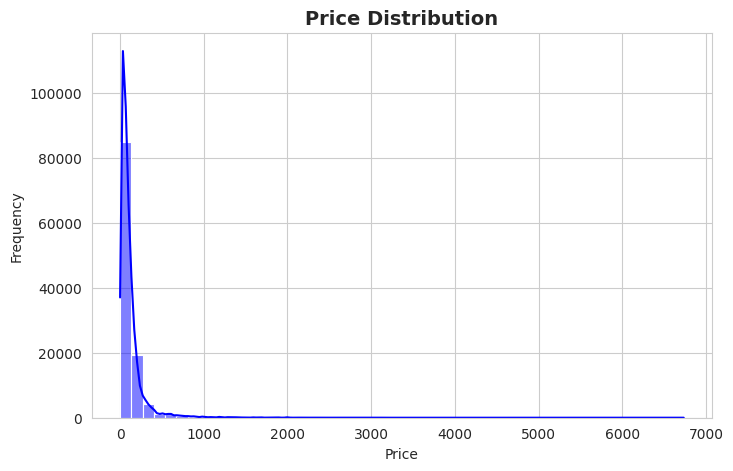

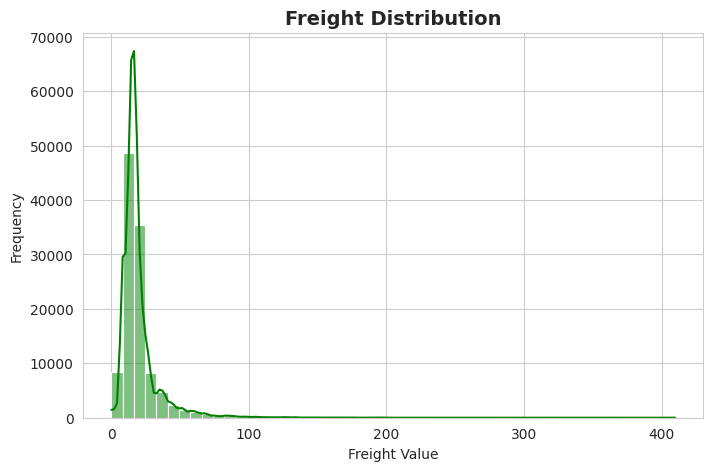

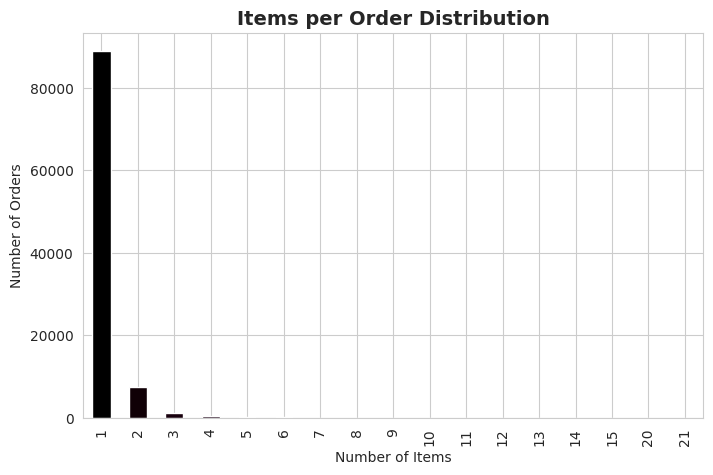

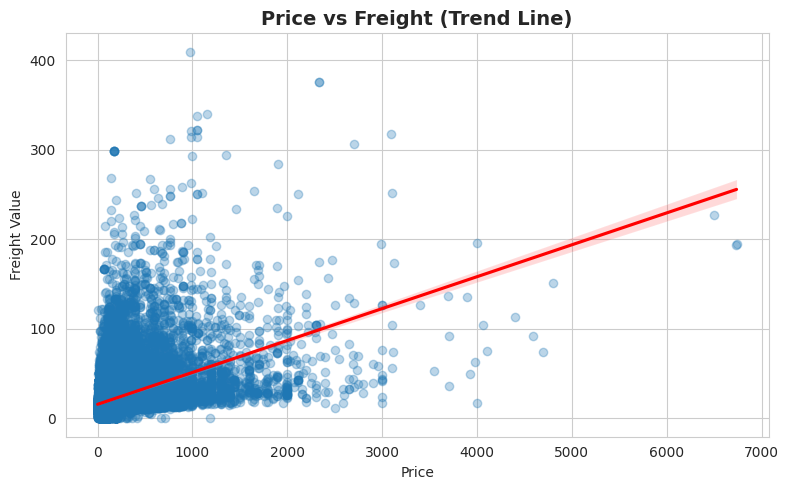

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('olist_order_items_dataset.csv')

# Style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8,5)

# -------------------------------
# 1. Price Distribution
# -------------------------------
plt.figure()
sns.histplot(items['price'], bins=50, kde=True, color='blue')
plt.title("Price Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

# -------------------------------
# 2. Freight Distribution
# -------------------------------
plt.figure()
sns.histplot(items['freight_value'], bins=50, kde=True, color='green')
plt.title("Freight Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Freight Value")
plt.ylabel("Frequency")
plt.show()

# -------------------------------
# 3. Items per Order
# -------------------------------
items_per_order = items.groupby('order_id')['order_item_id'].count().value_counts().sort_index()

plt.figure()
items_per_order.plot(kind='bar', color=plt.cm.gnuplot(range(len(items_per_order))))
plt.title("Items per Order Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Number of Items")
plt.ylabel("Number of Orders")
plt.show()

#4. Reg plot
sns.regplot(
    x='price',
    y='freight_value',
    data=items,
    scatter_kws={'alpha':0.3},
    line_kws={'color':'red'}
)

plt.title("Price vs Freight (Trend Line)", fontsize=14, fontweight='bold')
plt.xlabel("Price")
plt.ylabel("Freight Value")

plt.tight_layout()
plt.show()


- Total Items ↑ → Complexity ↑ → Delay ↑
- Price ↑ → Freight ↑ → Delay ↑
- Freight Value ↑ → Distance/Weight ↑ → Delay ↑

In [10]:
items['shipping_limit_date'] = pd.to_datetime(items['shipping_limit_date'])
items['Years'] = items['shipping_limit_date'].dt.year
items['Month'] = items['shipping_limit_date'].dt.month
items['Days']  = items['shipping_limit_date'].dt.day

In [11]:
items['Years'] = items['shipping_limit_date'].dt.year
items['Month'], items['Days'] = (items['shipping_limit_date'].dt.month, items['shipping_limit_date'].dt.day)
items['shipping_limit_date'] = pd.to_datetime(items['shipping_limit_date']).dt.date

/tmp/ipykernel_3330/4231468366.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=month.index, y=month.values, palette = 'gnuplot')


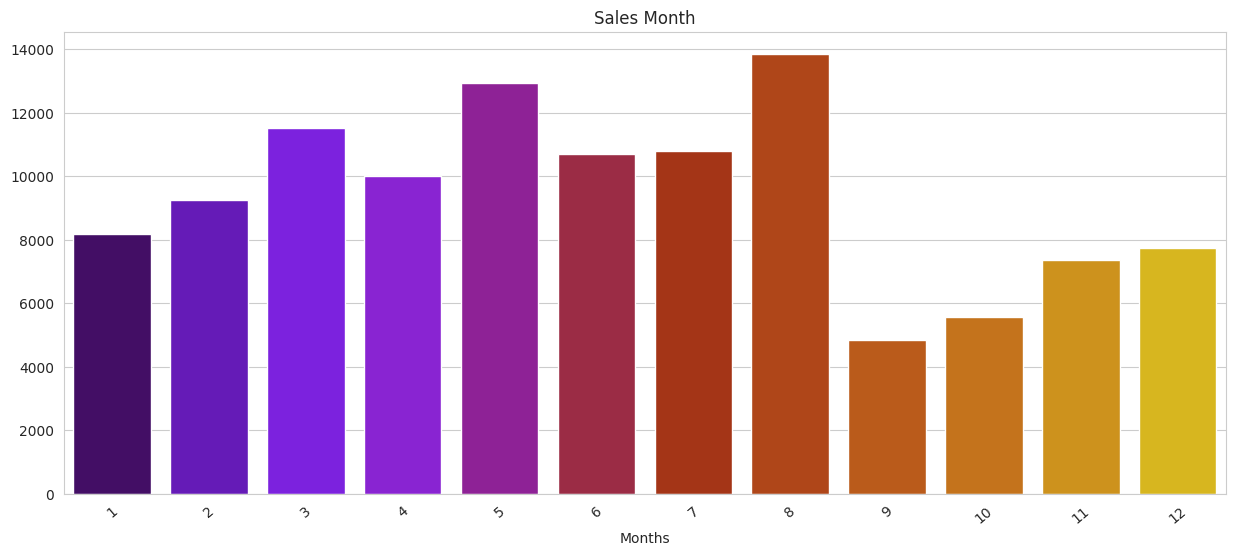

In [12]:
pl1 = plt.figure(figsize=(15,6))
month = items.groupby('Month')['product_id'].count().sort_values(ascending=False).head(112650)
sns.barplot(x=month.index, y=month.values, palette = 'gnuplot')
pl1 = pl1 = plt.xticks(rotation=40)
pl1 = plt.xlabel('Months')
pl1 = plt.title('Sales Month');
pl1 = plt.show()

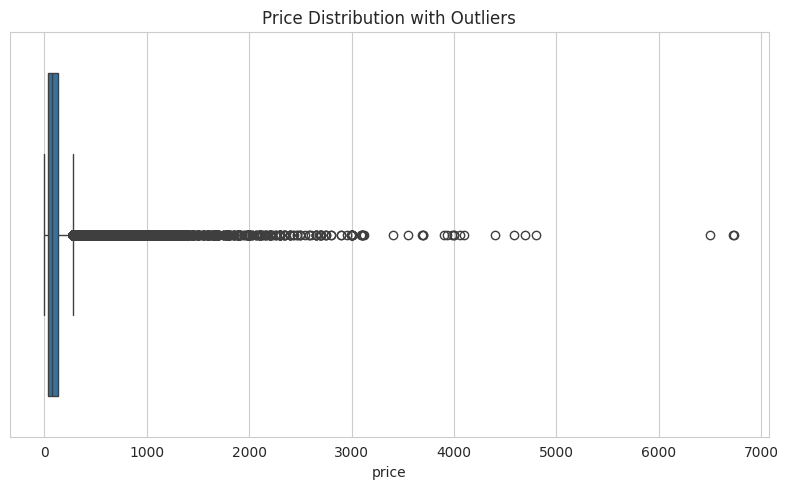

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(x=items['price'])

plt.title("Price Distribution with Outliers")

plt.tight_layout()
plt.show()

## 4. Payments

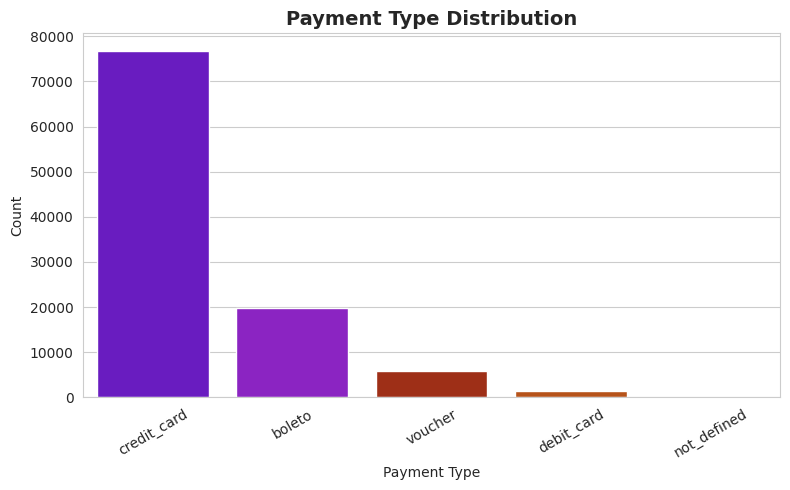

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()

sns.countplot(
    x='payment_type',
    data=payments,
    order=payments['payment_type'].value_counts().index,
    hue='payment_type',
    palette='gnuplot',
    legend=False
)

plt.title("Payment Type Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Payment Type")
plt.ylabel("Count")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


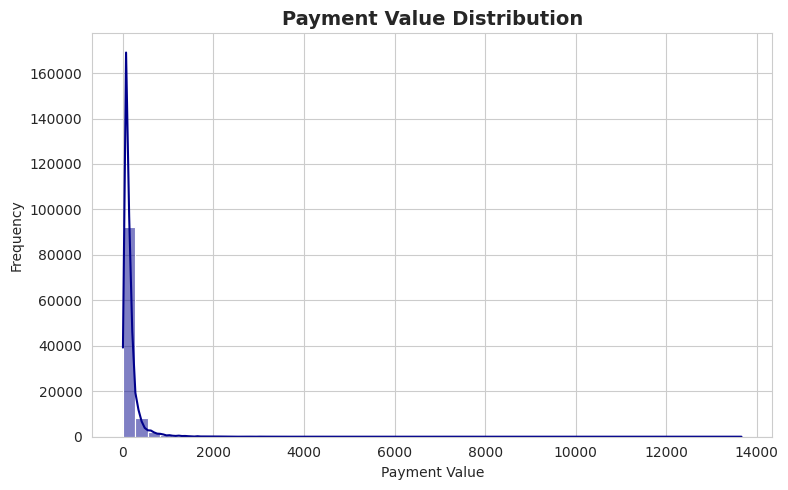

In [15]:
# -------------------------------
# 2. Payment Value Distribution
# -------------------------------
plt.figure()

sns.histplot(
    payments['payment_value'],
    bins=50,
    kde=True,
    color='darkblue'
)

plt.title("Payment Value Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Payment Value")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


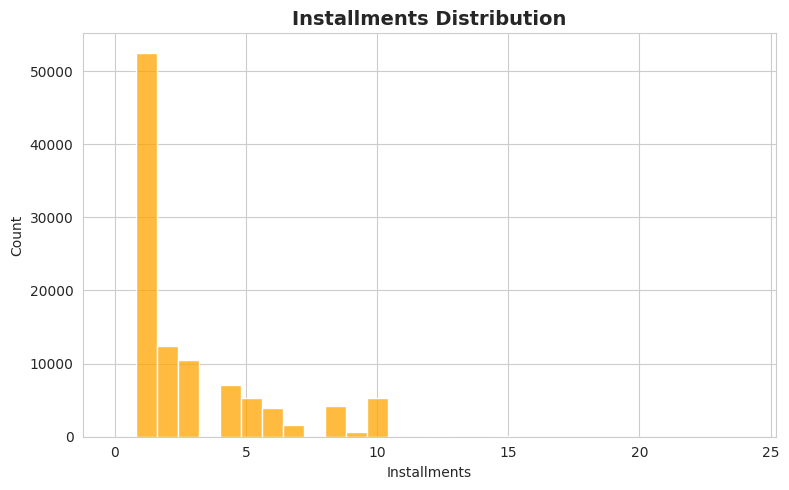

In [16]:
# 3. Installments Distribution
# -------------------------------
plt.figure()

sns.histplot(
   payments['payment_installments'],
    bins=30,
    color='orange'
)

plt.title("Installments Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Installments")
plt.ylabel("Count")

plt.tight_layout()
plt.show()


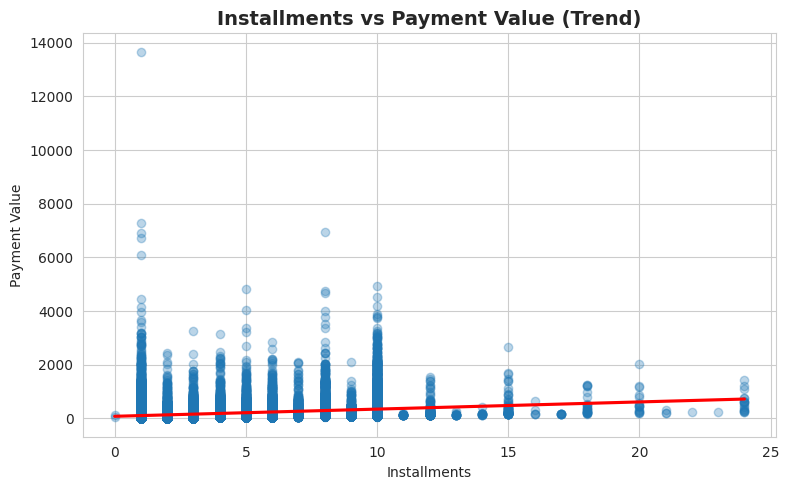

In [17]:
# -------------------------------
# 4. Installments vs Payment Value (Trend)
# -------------------------------
plt.figure()

sns.regplot(
    x='payment_installments',
    y='payment_value',
    data=payments,
    scatter_kws={'alpha':0.3},
    line_kws={'color':'red'}
)

plt.title("Installments vs Payment Value (Trend)", fontsize=14, fontweight='bold')
plt.xlabel("Installments")
plt.ylabel("Payment Value")

plt.tight_layout()
plt.show()

- Payment Type → Approval Speed → Delay
- Installments ↑ → Processing Time ↑ → Delay ↑
- Payment Value ↑ → Risk/Verification ↑ → Delay ↑

## 5. Reviews

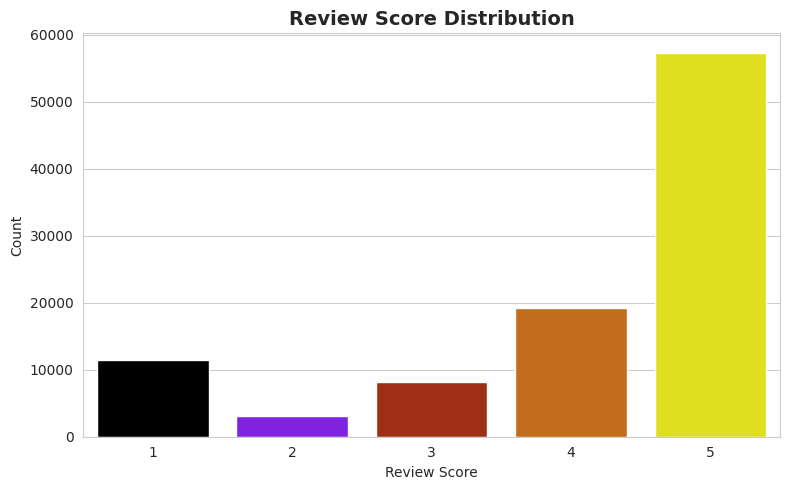

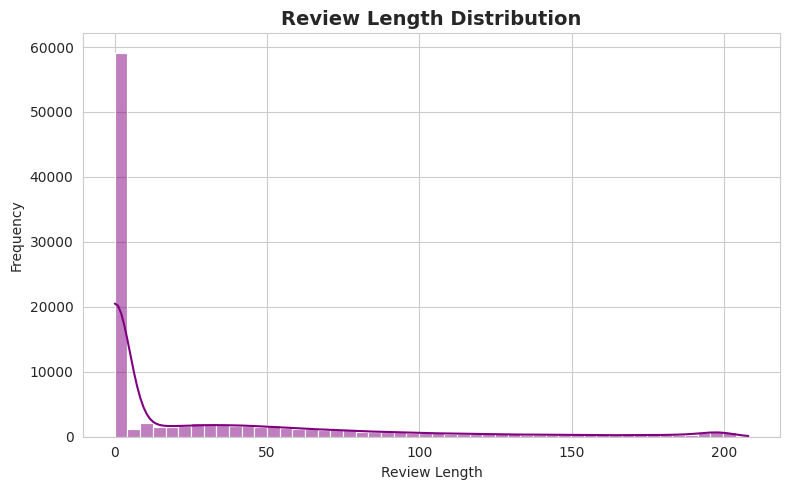

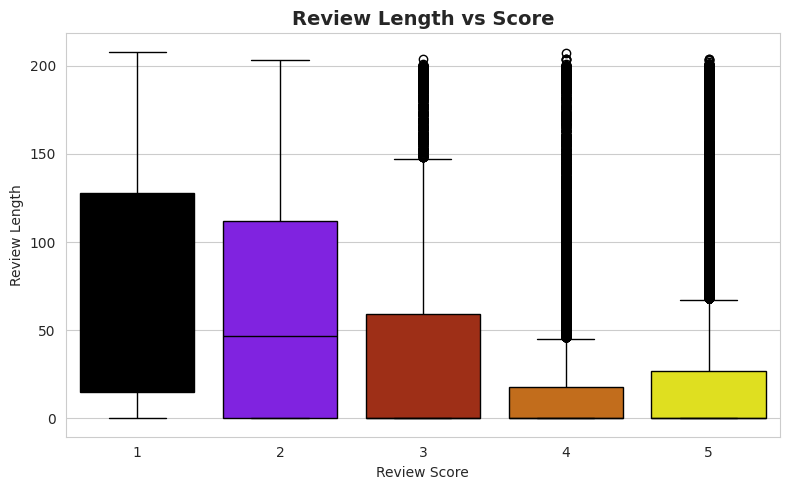

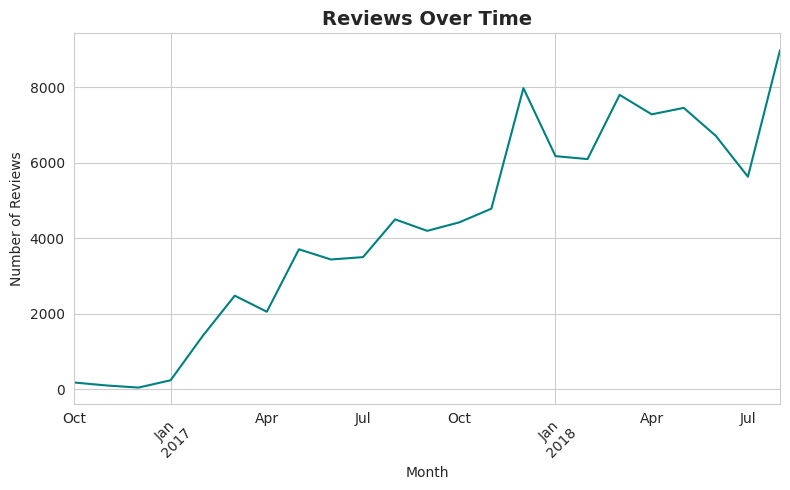

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8,5)

# Create review length feature
reviews['review_length'] = reviews['review_comment_message'].fillna('').apply(len)

# -------------------------------
# 1. Review Score Distribution
# -------------------------------
plt.figure()

sns.countplot(
    x='review_score',
    data=reviews,
    hue='review_score',
    palette='gnuplot',
    legend=False
)

plt.title("Review Score Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Review Score")
plt.ylabel("Count")

plt.tight_layout()
plt.show()


# -------------------------------
# 2. Review Length Distribution
# -------------------------------
plt.figure()

sns.histplot(
    reviews['review_length'],
    bins=50,
    kde=True,
    color='purple'
)

plt.title("Review Length Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Review Length")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


# -------------------------------
# 3. Review Length vs Score
# -------------------------------
plt.figure()

sns.boxplot(
    x='review_score',
    y='review_length',
    data=reviews,
    hue='review_score',
    palette='gnuplot',
    legend=False
)

plt.title("Review Length vs Score", fontsize=14, fontweight='bold')
plt.xlabel("Review Score")
plt.ylabel("Review Length")

plt.tight_layout()
plt.show()


# -------------------------------
# 4. Reviews Over Time
# -------------------------------
reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'])

review_trend = reviews.groupby(reviews['review_creation_date'].dt.to_period('M')).size()

plt.figure()

review_trend.plot(color='teal')

plt.title("Reviews Over Time", fontsize=14, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- Low Review Score → Bad Delivery Experience → Delay
- Review Length ↑ → Complaint ↑ → Delay Likely
- High Volume (time) → Logistics Pressure → Delay Risk
- review_score vs is_delayed  🔥

## 6. Orders

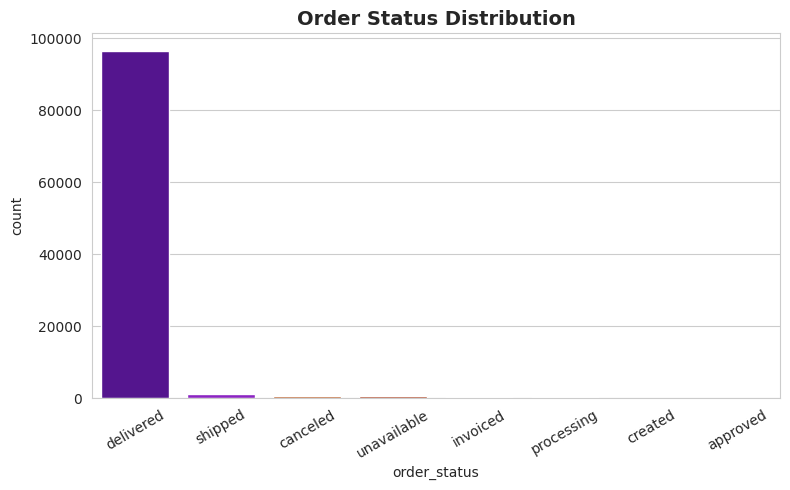

In [19]:
plt.figure()

sns.countplot(
    x='order_status',
    data=orders,
    order=orders['order_status'].value_counts().index,
    hue='order_status',
    palette='gnuplot',
    legend=False
)

plt.title("Order Status Distribution", fontsize=14, fontweight='bold')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

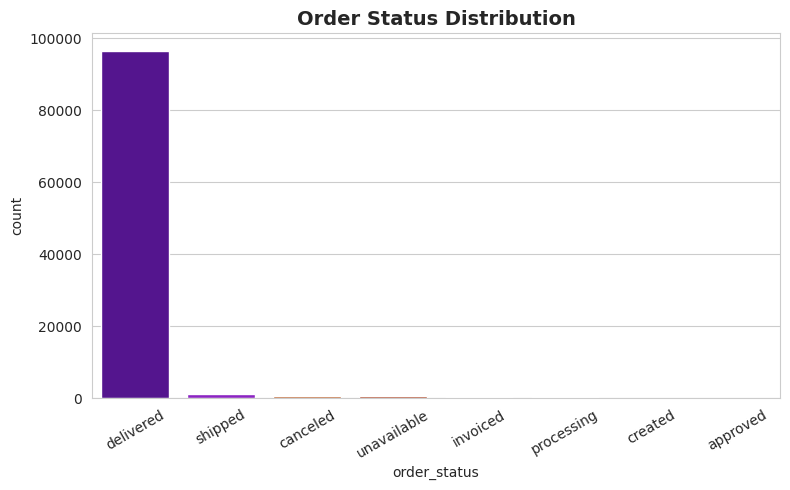

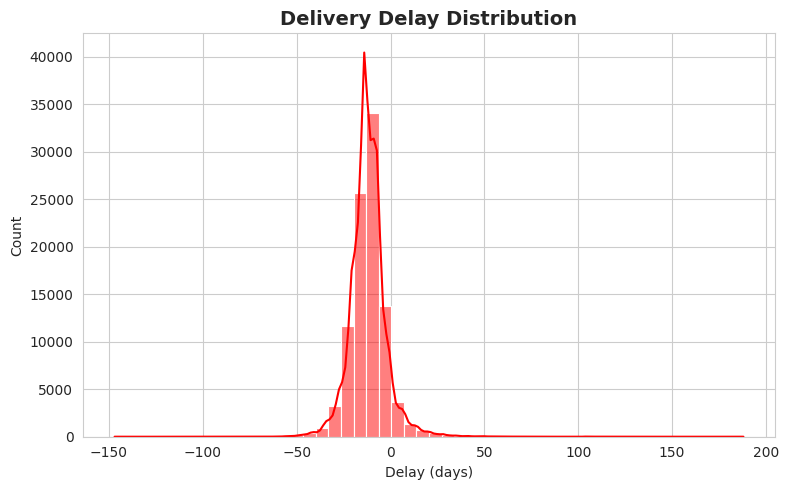

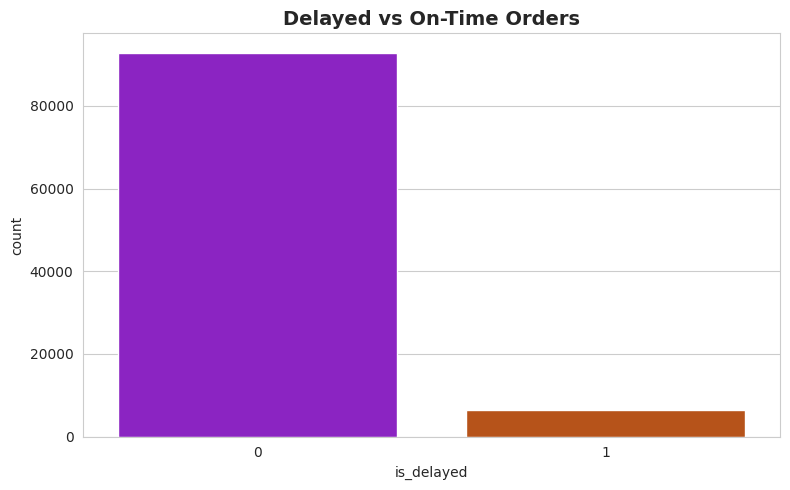

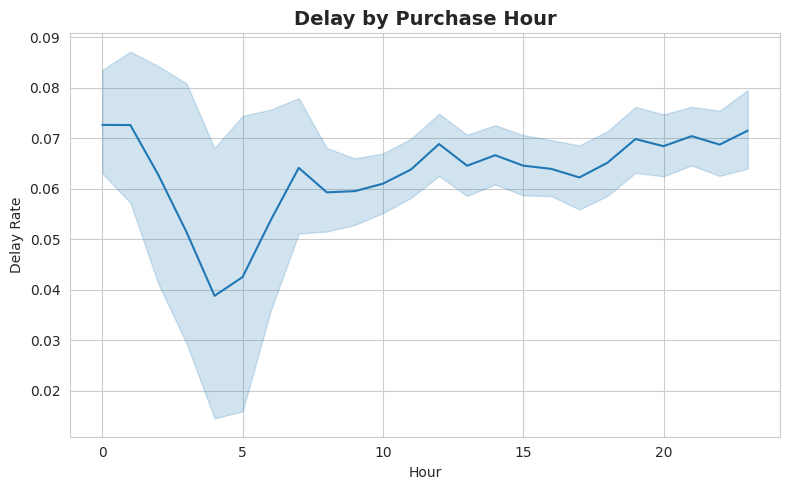

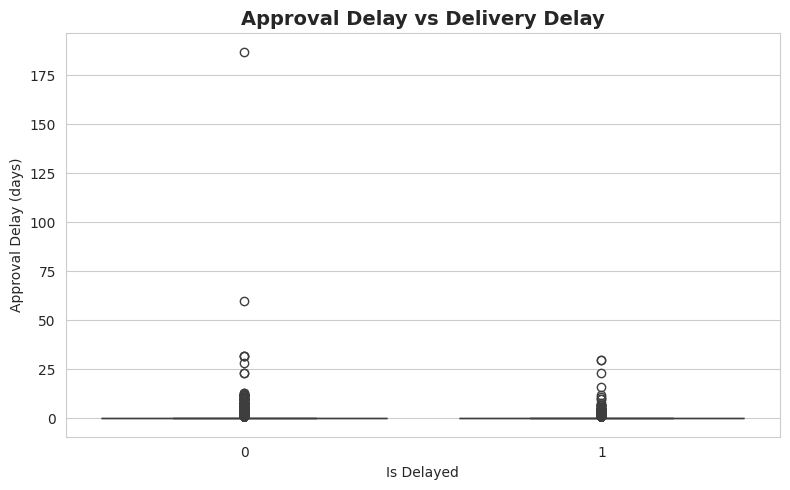

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Styling
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8,5)

# -------------------------------
# Convert Dates
# -------------------------------
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

# -------------------------------
# Feature Creation
# -------------------------------
orders['delivery_delay'] = (
    orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']
).dt.days

orders['is_delayed'] = (orders['delivery_delay'] > 0).astype(int)

orders['purchase_hour'] = orders['order_purchase_timestamp'].dt.hour

orders['approval_delay'] = (
    orders['order_approved_at'] - orders['order_purchase_timestamp']
).dt.days

# -------------------------------
# 1. Order Status
# -------------------------------
plt.figure()

sns.countplot(
    x='order_status',
    data=orders,
    order=orders['order_status'].value_counts().index,
    hue='order_status',
    palette='gnuplot',
    legend=False
)

plt.title("Order Status Distribution", fontsize=14, fontweight='bold')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# -------------------------------
# 2. Delivery Delay Distribution
# -------------------------------
plt.figure()

sns.histplot(
    orders['delivery_delay'].dropna(),
    bins=50,
    kde=True,
    color='red'
)

plt.title("Delivery Delay Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Delay (days)")
plt.tight_layout()
plt.show()


# -------------------------------
# 3. Delayed vs On-Time
# -------------------------------
plt.figure()

sns.countplot(
    x='is_delayed',
    data=orders,
    hue='is_delayed',
    palette='gnuplot',
    legend=False
)

plt.title("Delayed vs On-Time Orders", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# -------------------------------
# 4. Purchase Hour vs Delay
# -------------------------------
plt.figure()

sns.lineplot(
    x='purchase_hour',
    y='is_delayed',
    data=orders
)

plt.title("Delay by Purchase Hour", fontsize=14, fontweight='bold')
plt.xlabel("Hour")
plt.ylabel("Delay Rate")
plt.tight_layout()
plt.show()


# -------------------------------
# 5. Approval Delay vs Delivery Delay
# -------------------------------
plt.figure()

sns.boxplot(
    x='is_delayed',
    y='approval_delay',
    data=orders,
    hue='is_delayed',
    palette='gnuplot',
    legend=False
)

plt.title("Approval Delay vs Delivery Delay", fontsize=14, fontweight='bold')
plt.xlabel("Is Delayed")
plt.ylabel("Approval Delay (days)")
plt.tight_layout()
plt.show()

- Approval Delay ↑ → Delivery Delay ↑
- Purchase Time → Operational Load → Delay
- Order Status → Delivery Outcome
- Early Delivery vs Late Delivery → Performance Indicator

## 7. Products

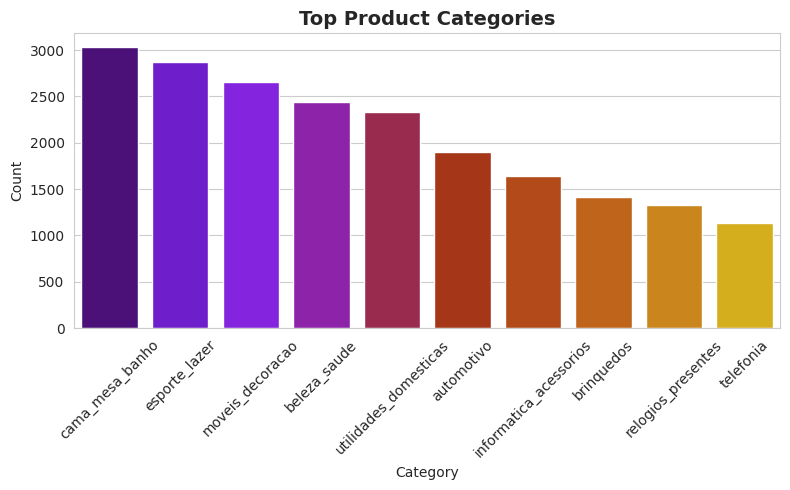

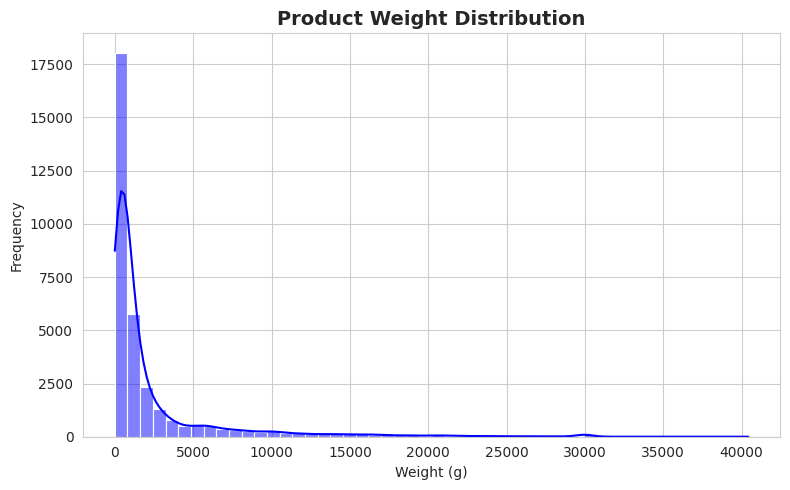

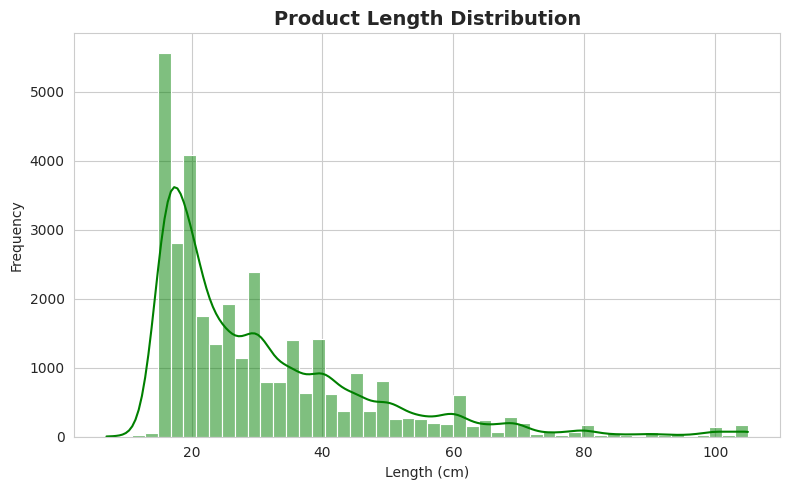

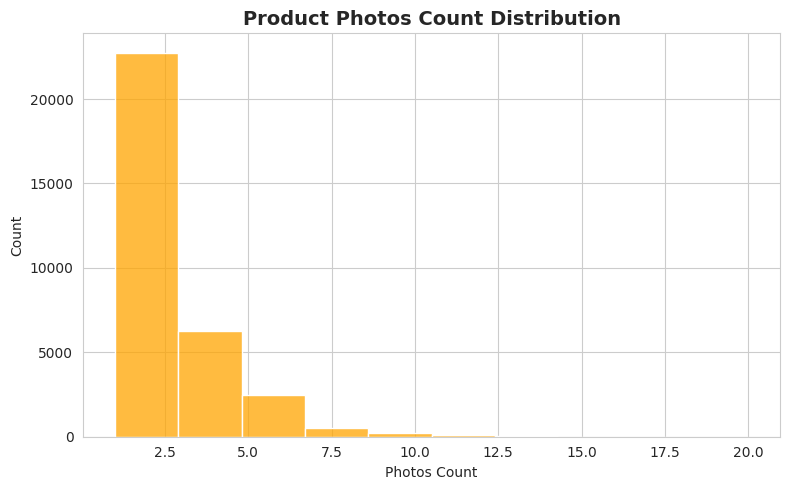

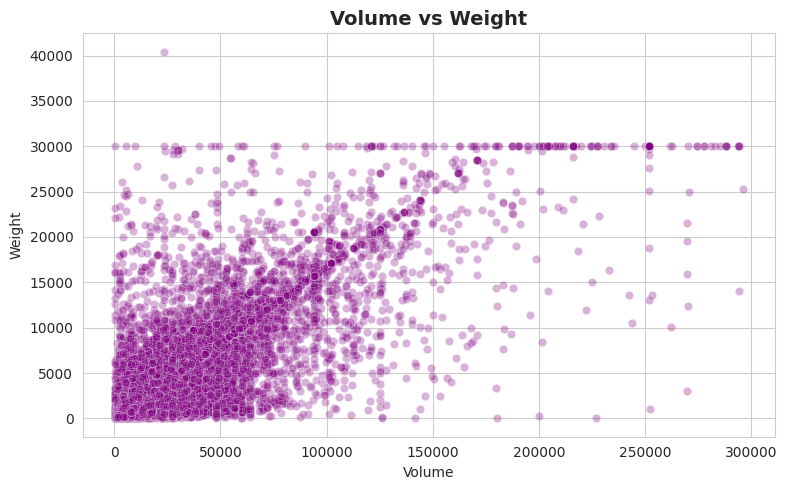

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8,5)

# Create volume feature
products['volume'] = (
    products['product_length_cm'] *
    products['product_height_cm'] *
    products['product_width_cm']
)

# -------------------------------
# 1. Top Product Categories
# -------------------------------
top_categories = products['product_category_name'].value_counts().head(10)

plt.figure()

sns.barplot(
    x=top_categories.index,
    y=top_categories.values,
    hue=top_categories.index,
    palette='gnuplot',
    legend=False
)

plt.title("Top Product Categories", fontsize=14, fontweight='bold')
plt.xlabel("Category")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# -------------------------------
# 2. Product Weight Distribution
# -------------------------------
plt.figure()

sns.histplot(
    products['product_weight_g'],
    bins=50,
    kde=True,
    color='blue'
)

plt.title("Product Weight Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Weight (g)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


# -------------------------------
# 3. Product Length Distribution
# -------------------------------
plt.figure()

sns.histplot(
    products['product_length_cm'],
    bins=50,
    kde=True,
    color='green'
)

plt.title("Product Length Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Length (cm)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


# -------------------------------
# 4. Product Photos Count
# -------------------------------
plt.figure()

sns.histplot(
    products['product_photos_qty'],
    bins=10,
    color='orange'
)

plt.title("Product Photos Count Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Photos Count")
plt.ylabel("Count")

plt.tight_layout()
plt.show()


# -------------------------------
# 5. Volume vs Weight (Key Relationship)
# -------------------------------
plt.figure()

sns.scatterplot(
    x='volume',
    y='product_weight_g',
    data=products,
    alpha=0.3,
    color='purple'
)

plt.title("Volume vs Weight", fontsize=14, fontweight='bold')
plt.xlabel("Volume")
plt.ylabel("Weight")

plt.tight_layout()
plt.show()

- Weight ↑ → Delay ↑
- Volume ↑ → Logistics Complexity ↑ → Delay ↑
- Product Category → Delivery Behavior

- volume vs is_delayed
- weight vs is_delayed
- category vs is_delayed

## 8. Sellers

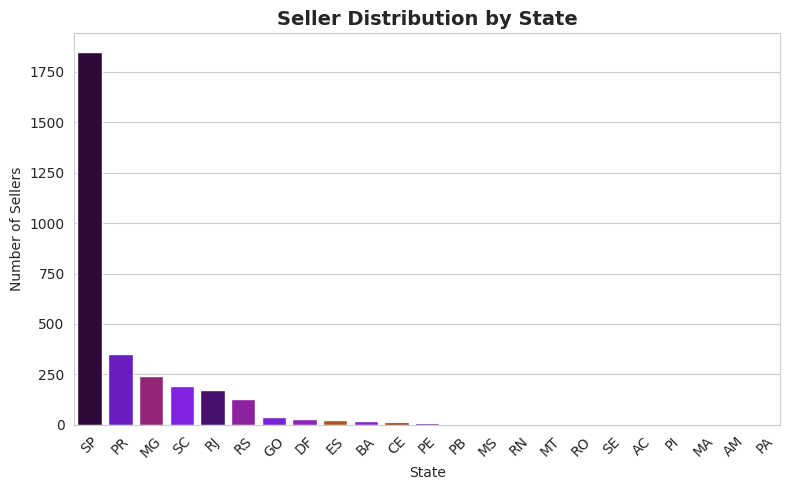

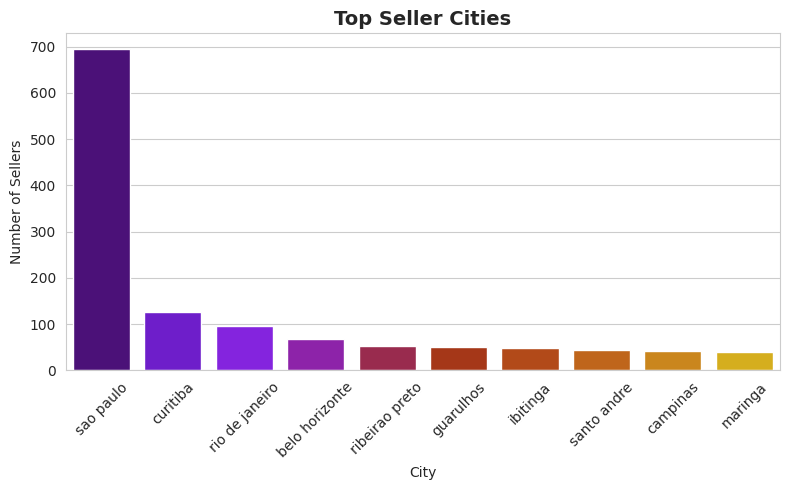

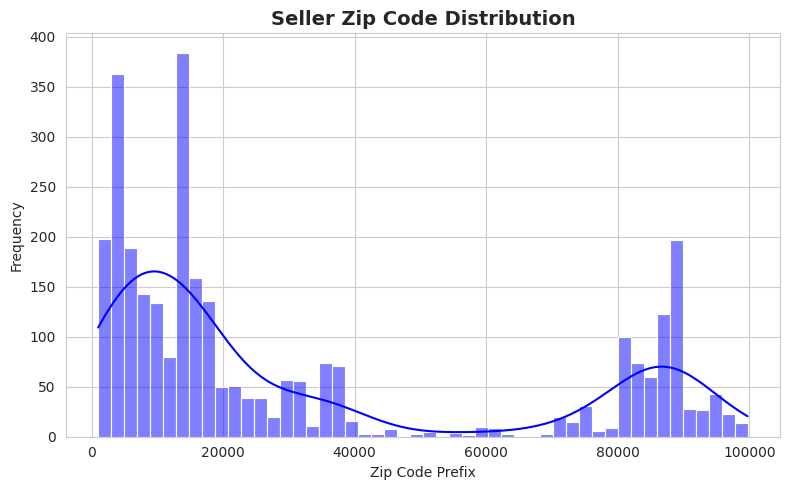

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8,5)

# -------------------------------
# 1. Seller State Distribution
# -------------------------------
plt.figure()

sns.countplot(
    x='seller_state',
    data=sellers,
    order=sellers['seller_state'].value_counts().index,
    hue='seller_state',
    palette='gnuplot',
    legend=False
)

plt.title("Seller Distribution by State", fontsize=14, fontweight='bold')
plt.xlabel("State")
plt.ylabel("Number of Sellers")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# -------------------------------
# 2. Top Seller Cities
# -------------------------------
top_cities = sellers['seller_city'].value_counts().head(10)

plt.figure()

sns.barplot(
    x=top_cities.index,
    y=top_cities.values,
    hue=top_cities.index,
    palette='gnuplot',
    legend=False
)

plt.title("Top Seller Cities", fontsize=14, fontweight='bold')
plt.xlabel("City")
plt.ylabel("Number of Sellers")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# -------------------------------
# 3. Seller Zip Code Distribution
# -------------------------------
plt.figure()

sns.histplot(
    sellers['seller_zip_code_prefix'],
    bins=50,
    kde=True,
    color='blue'
)

plt.title("Seller Zip Code Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Zip Code Prefix")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()



- Customer Location ≠ Seller Location → Distance ↑ → Delay ↑
- Seller Density ↓ → Delivery Time ↑ → Delay ↑
- Urban Sellers → Faster Delivery
- Rural Sellers → Slower Delivery

- customer_state vs seller_state → delay
- distance = seller_location - customer_location

## 9. Category

Total Unique Categories: 71


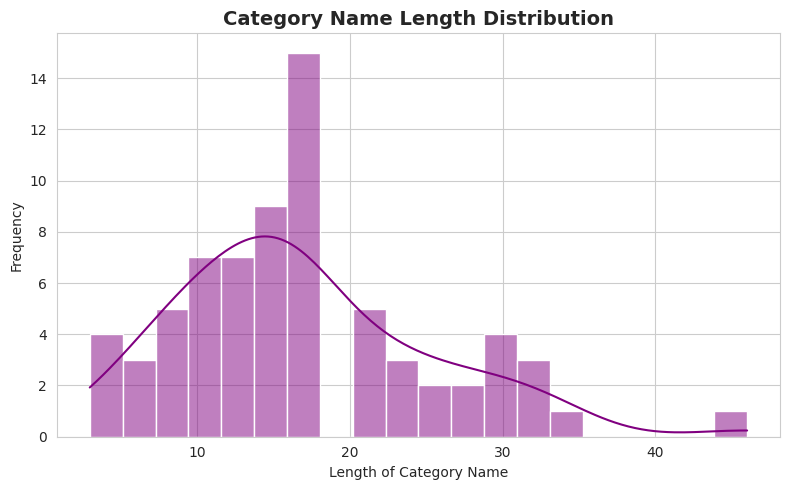

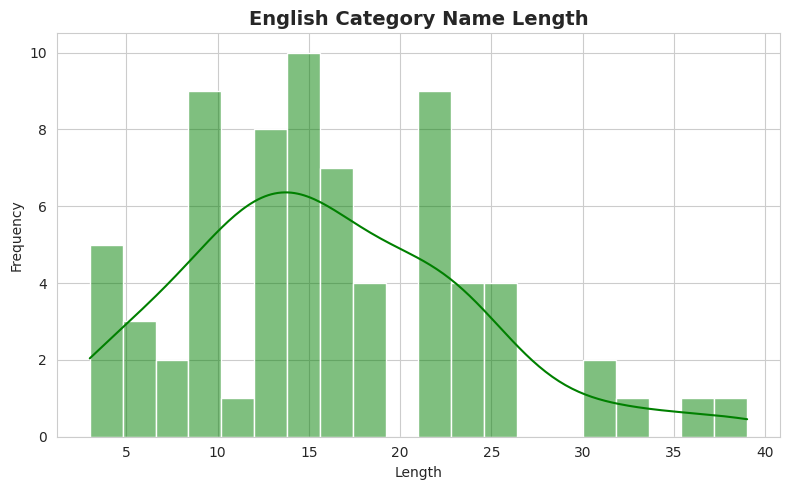

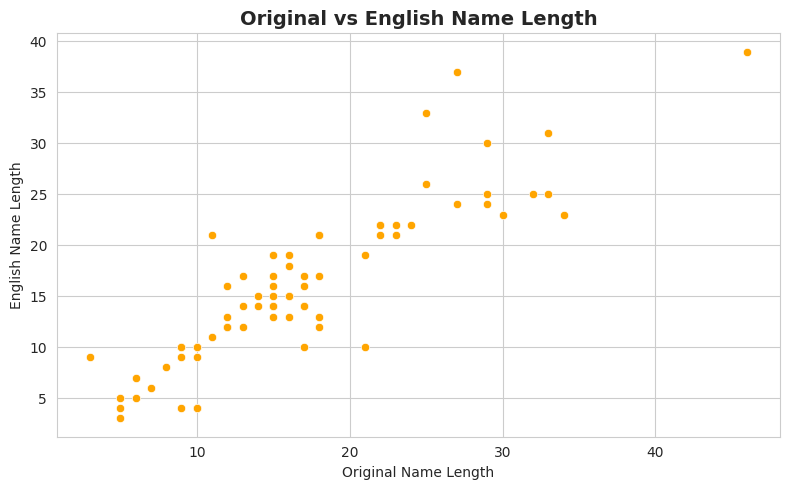

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8,5)

# -------------------------------
# 1. Total Unique Categories
# -------------------------------
print("Total Unique Categories:", cat['product_category_name'].nunique())


# -------------------------------
# 2. Category Name Length
# -------------------------------
cat['name_length'] = cat['product_category_name'].apply(len)

plt.figure()

sns.histplot(
    cat['name_length'],
    bins=20,
    kde=True,
    color='purple'
)

plt.title("Category Name Length Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Length of Category Name")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


# -------------------------------
# 3. English Name Length
# -------------------------------
cat['eng_length'] = cat['product_category_name_english'].apply(len)

plt.figure()

sns.histplot(
    cat['eng_length'],
    bins=20,
    kde=True,
    color='green'
)

plt.title("English Category Name Length", fontsize=14, fontweight='bold')
plt.xlabel("Length")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


# -------------------------------
# 4. Original vs English Mapping
# -------------------------------
plt.figure()

sns.scatterplot(
    x='name_length',
    y='eng_length',
    data=cat,
    color='orange'
)

plt.title("Original vs English Name Length", fontsize=14, fontweight='bold')
plt.xlabel("Original Name Length")
plt.ylabel("English Name Length")

plt.tight_layout()
plt.show()

- Feature Engineering : product_category_name → product_category_name_english

- Product Category → (Products) Product Type → Delivery Complexity → Delay




In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import radians, sin, cos, sqrt, atan2

# ── Visual style ──────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})
DELAY_COLOR   = "#E24B4A"   # red   → delayed
ON_TIME_COLOR = "#1D9E75"   # teal  → on time
NEUTRAL_COLOR = "#7F77DD"   # purple → neutral/highlight

# ── Load all 9 tables ─────────────────────────────────────
orders     = pd.read_csv("olist_orders_dataset.csv")
customers  = pd.read_csv("olist_customers_dataset.csv")
items      = pd.read_csv("olist_order_items_dataset.csv")
payments   = pd.read_csv("olist_order_payments_dataset.csv")
reviews    = pd.read_csv("olist_order_reviews_dataset.csv")
products   = pd.read_csv("olist_products_dataset.csv")
sellers    = pd.read_csv("olist_sellers_dataset.csv")
geo        = pd.read_csv("olist_geolocation_dataset.csv")
cat_trans  = pd.read_csv("product_category_name_translation.csv")

# ── Parse timestamps ──────────────────────────────────────
date_cols = [
    "order_purchase_timestamp", "order_approved_at",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date"
]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

# ── Filter: delivered orders only ─────────────────────────
df = orders[orders["order_status"] == "delivered"].copy()
df = df.dropna(subset=["order_delivered_customer_date",
                        "order_estimated_delivery_date"])

# ── Target variable ───────────────────────────────────────
df["is_delayed"] = (
    df["order_delivered_customer_date"] > df["order_estimated_delivery_date"]
).astype(int)

print(f"Total delivered orders : {len(df):,}")
print(f"Delayed orders         : {df['is_delayed'].sum():,}  "
      f"({df['is_delayed'].mean()*100:.1f}%)")
print(f"On-time orders         : {(df['is_delayed']==0).sum():,}  "
      f"({(df['is_delayed']==0).mean()*100:.1f}%)")

Total delivered orders : 96,470
Delayed orders         : 7,826  (8.1%)
On-time orders         : 88,644  (91.9%)


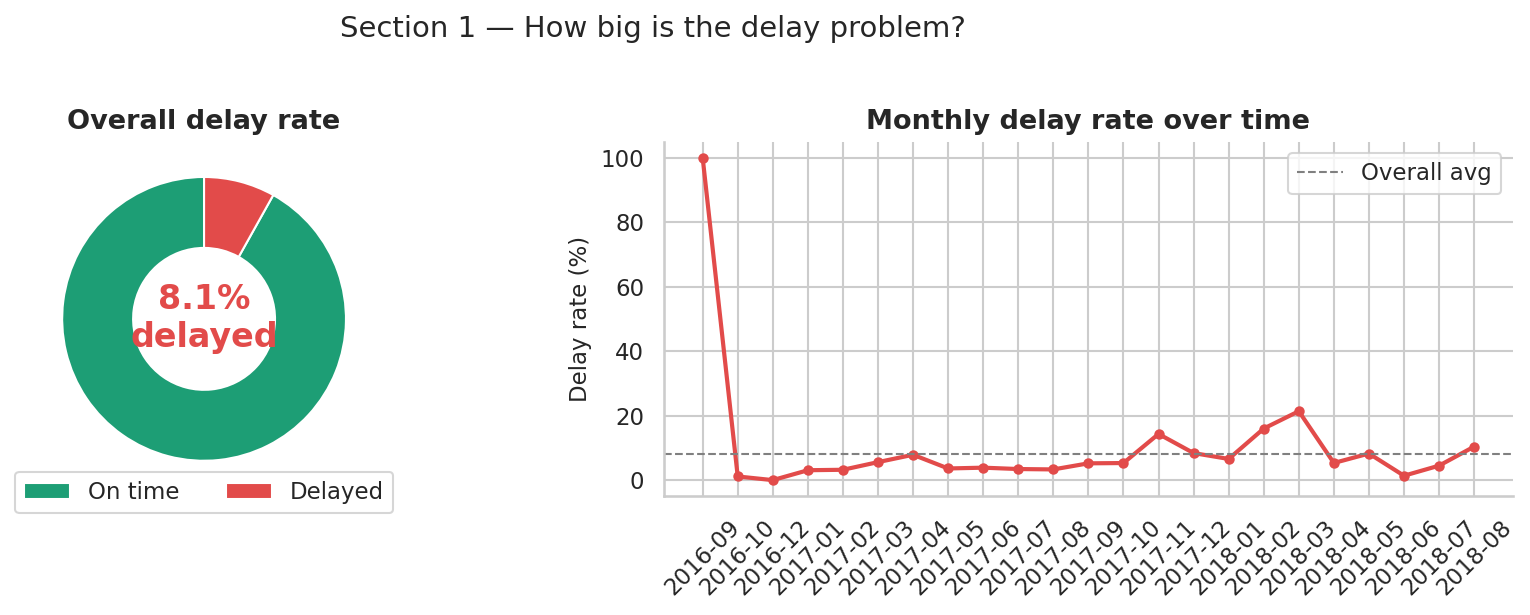

In [25]:
# ── 1A. Overall delay rate — headline number ───────────────
delay_rate = df["is_delayed"].mean()
on_time    = 1 - delay_rate

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Donut chart
sizes  = [on_time, delay_rate]
colors = [ON_TIME_COLOR, DELAY_COLOR]
wedges, _ = axes[0].pie(sizes, colors=colors, startangle=90,
                         wedgeprops=dict(width=0.5))
axes[0].text(0, 0, f"{delay_rate*100:.1f}%\ndelayed",
             ha="center", va="center", fontsize=16, fontweight="bold",
             color=DELAY_COLOR)
axes[0].set_title("Overall delay rate")
axes[0].legend(["On time", "Delayed"], loc="lower center",
               bbox_to_anchor=(0.5, -0.08), ncol=2)

# Month-over-month delay rate trend
df["month"] = df["order_purchase_timestamp"].dt.to_period("M")
monthly = df.groupby("month")["is_delayed"].mean().reset_index()
monthly["month_str"] = monthly["month"].astype(str)

axes[1].plot(monthly["month_str"], monthly["is_delayed"] * 100,
             color=DELAY_COLOR, linewidth=2, marker="o", markersize=4)
axes[1].axhline(delay_rate * 100, linestyle="--",
                color="gray", linewidth=1, label="Overall avg")
axes[1].set_title("Monthly delay rate over time")
axes[1].set_ylabel("Delay rate (%)")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend()

plt.suptitle("Section 1 — How big is the delay problem?",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("eda_01_delay_rate.png", bbox_inches="tight")
plt.show()

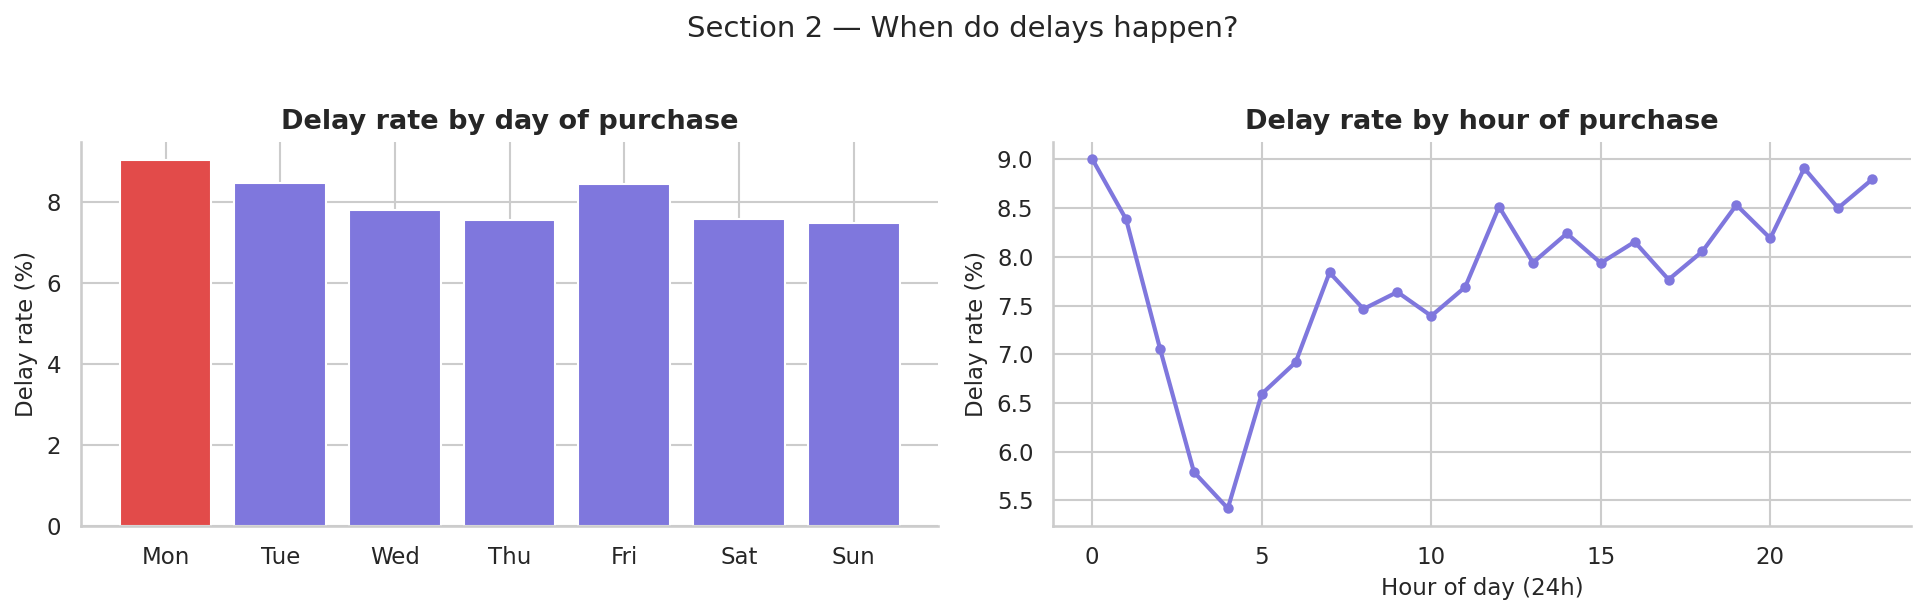

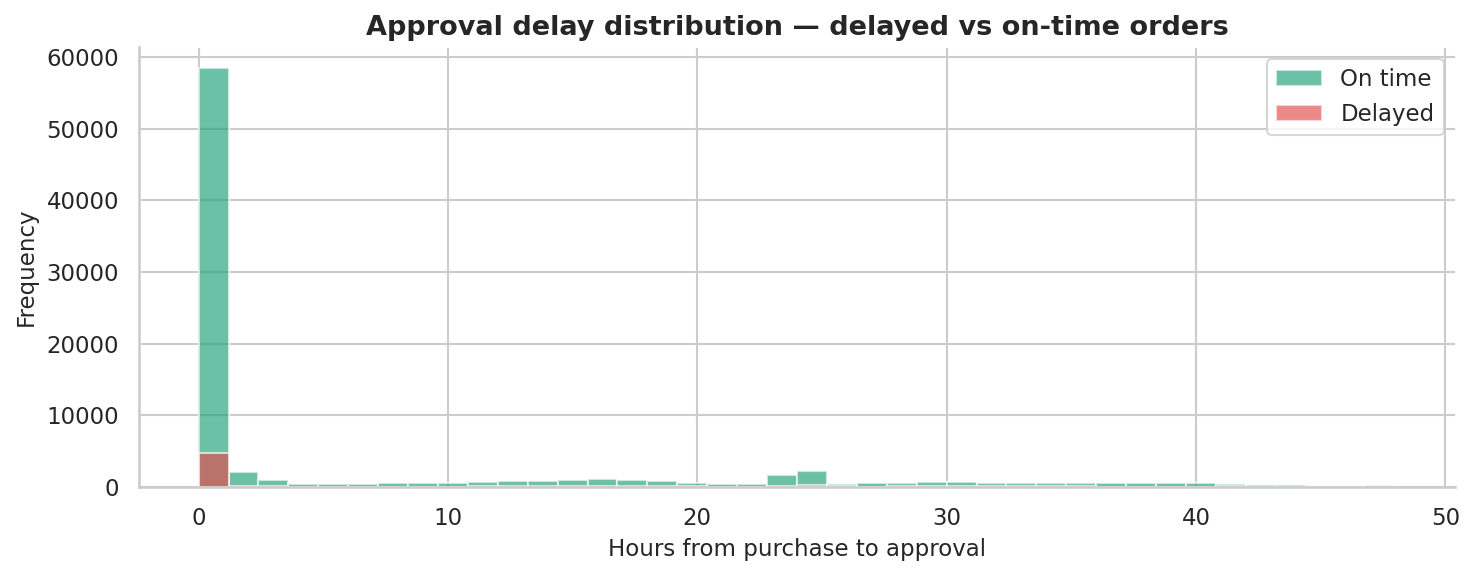

In [27]:
df["dow"]  = df["order_purchase_timestamp"].dt.dayofweek   # 0=Mon
df["hour"] = df["order_purchase_timestamp"].dt.hour

dow_labels  = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
dow_delay   = df.groupby("dow")["is_delayed"].mean() * 100
hour_delay  = df.groupby("hour")["is_delayed"].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(dow_labels, dow_delay, color=[
    DELAY_COLOR if v == dow_delay.max() else NEUTRAL_COLOR
    for v in dow_delay])
axes[0].set_title("Delay rate by day of purchase")
axes[0].set_ylabel("Delay rate (%)")

axes[1].plot(hour_delay.index, hour_delay.values,
             color=NEUTRAL_COLOR, linewidth=2, marker="o", markersize=4)
axes[1].set_title("Delay rate by hour of purchase")
axes[1].set_ylabel("Delay rate (%)")
axes[1].set_xlabel("Hour of day (24h)")

plt.suptitle("Section 2 — When do delays happen?", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("eda_02_time_trends.png", bbox_inches="tight")
plt.show()

# ── 2B. Approval delay distribution ───────────────────────
df["approval_delay_hrs"] = (
    df["order_approved_at"] - df["order_purchase_timestamp"]
).dt.total_seconds() / 3600

fig, ax = plt.subplots(figsize=(10, 4))

# Iterate through the groups and plot each histogram with the respective color
for is_delayed_val, group_df in df[df["approval_delay_hrs"] < 48].groupby("is_delayed"):
    color = DELAY_COLOR if is_delayed_val == 1 else ON_TIME_COLOR
    label = "Delayed" if is_delayed_val == 1 else "On time"
    group_df["approval_delay_hrs"].plot(
        kind="hist", bins=40, alpha=0.65, ax=ax,
        color=color, label=label
    )

ax.set_xlabel("Hours from purchase to approval")
ax.set_title("Approval delay distribution — delayed vs on-time orders")
ax.legend()
plt.tight_layout()
plt.savefig("eda_02b_approval_delay.png", bbox_inches="tight")
plt.show()

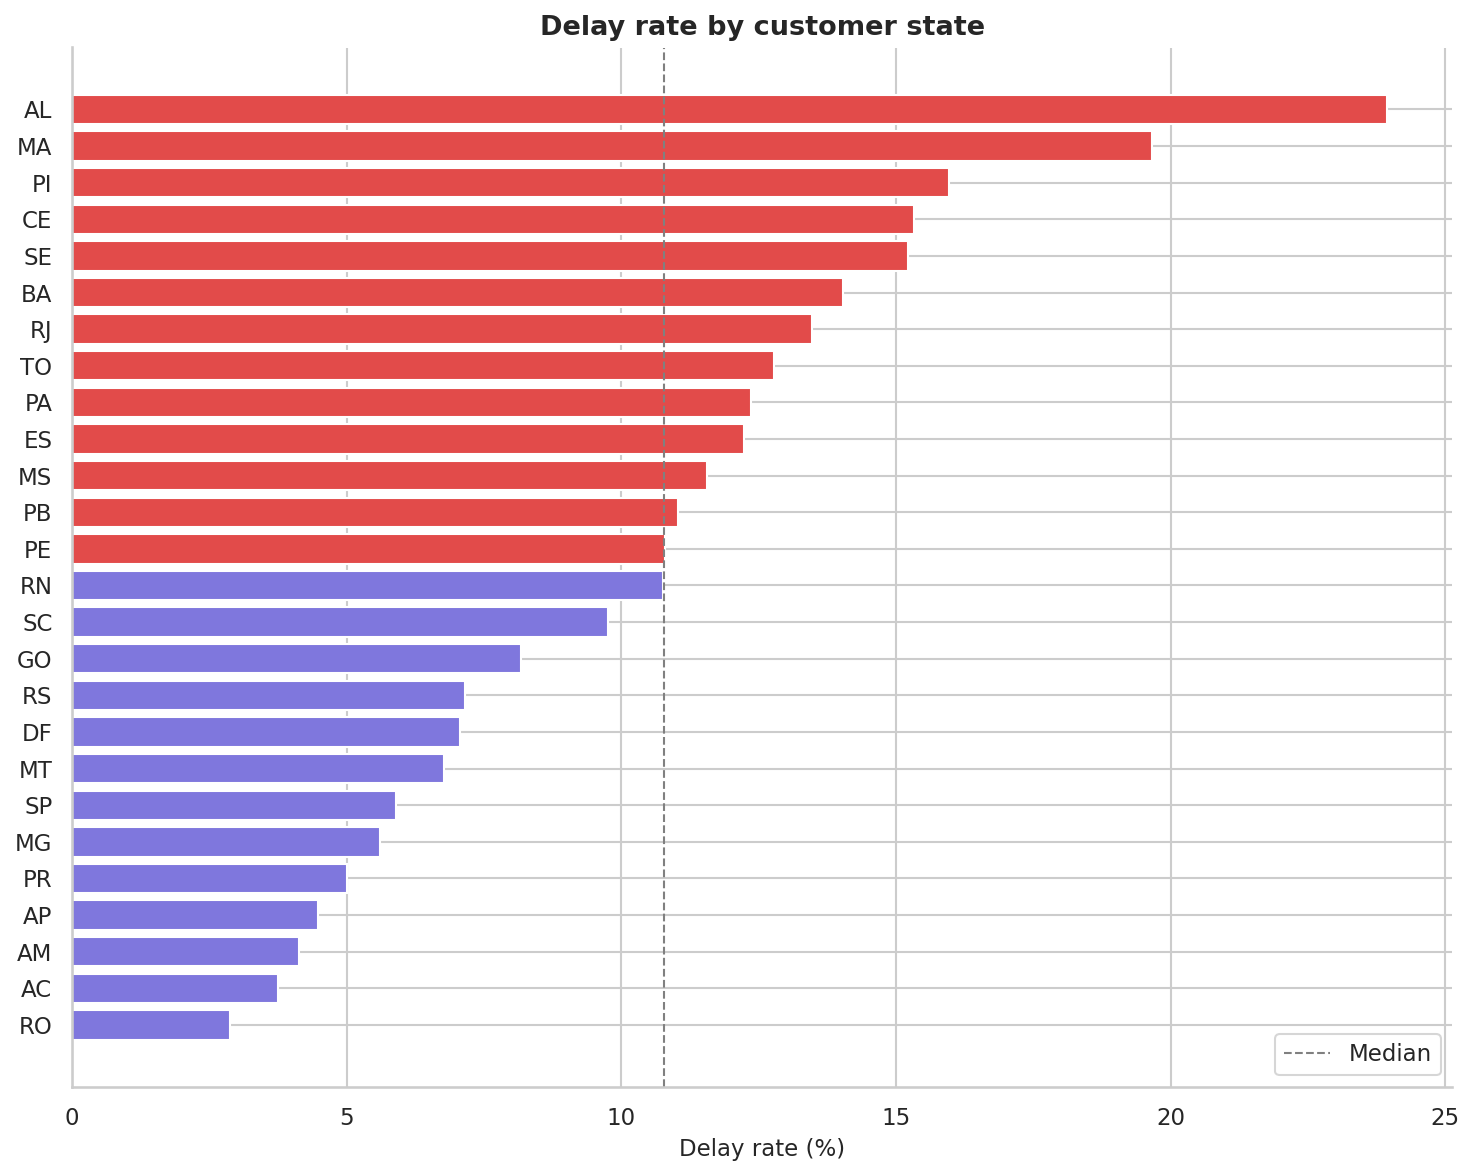

/tmp/ipykernel_3330/168981302.py:70: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dist_delay = df_geo.groupby("dist_bin")["is_delayed"].mean() * 100


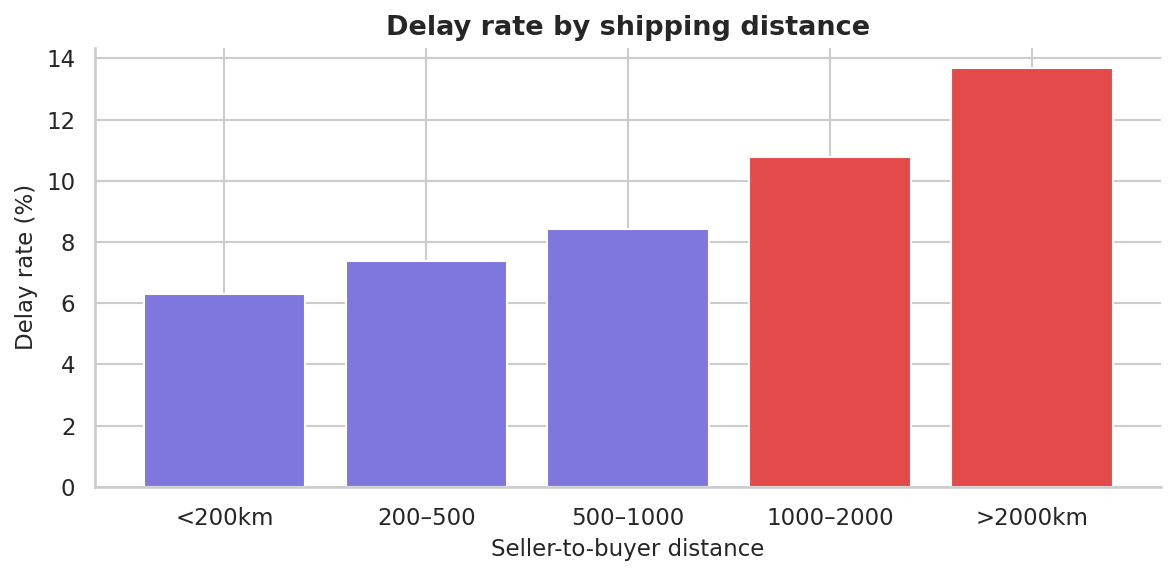

In [28]:
# ── 3A. Delay rate by customer state ─────────────────────
df_cust = df.merge(customers[["customer_id","customer_state"]],
                   on="customer_id", how="left")

state_stats = df_cust.groupby("customer_state").agg(
    total=("is_delayed","count"),
    delayed=("is_delayed","sum")
).reset_index()
state_stats["delay_rate"] = state_stats["delayed"] / state_stats["total"] * 100
state_stats = state_stats[state_stats["total"] > 50]   # enough samples
state_stats = state_stats.sort_values("delay_rate", ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = [DELAY_COLOR if v > state_stats["delay_rate"].median()
          else NEUTRAL_COLOR for v in state_stats["delay_rate"]]
ax.barh(state_stats["customer_state"], state_stats["delay_rate"], color=colors)
ax.axvline(state_stats["delay_rate"].median(), linestyle="--",
           color="gray", linewidth=1, label="Median")
ax.set_xlabel("Delay rate (%)")
ax.set_title("Delay rate by customer state")
ax.legend()
plt.tight_layout()
plt.savefig("eda_03_geo_state.png", bbox_inches="tight")
plt.show()

# ── 3B. Distance vs delay ─────────────────────────────────
# Aggregate geo to one lat/lng per zip prefix
geo_agg = geo.groupby("geolocation_zip_code_prefix").agg(
    lat=("geolocation_lat","mean"),
    lng=("geolocation_lng","mean")
).reset_index()

# Join seller locations
items_sel = items.merge(sellers[["seller_id","seller_zip_code_prefix"]],
                         on="seller_id", how="left")
items_sel = items_sel.merge(geo_agg.rename(columns={
    "geolocation_zip_code_prefix":"seller_zip_code_prefix",
    "lat":"seller_lat","lng":"seller_lng"}),
    on="seller_zip_code_prefix", how="left")

# Join customer locations
df_geo = df_cust.merge(
    customers[["customer_id","customer_zip_code_prefix"]], on="customer_id", how="left")
df_geo = df_geo.merge(geo_agg.rename(columns={
    "geolocation_zip_code_prefix":"customer_zip_code_prefix",
    "lat":"cust_lat","lng":"cust_lng"}),
    on="customer_zip_code_prefix", how="left")

# One seller per order (most expensive item's seller)
top_item = items_sel.sort_values("price", ascending=False).drop_duplicates("order_id")
df_geo = df_geo.merge(top_item[["order_id","seller_lat","seller_lng"]],
                       on="order_id", how="left")

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1; dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1 - a))

df_geo = df_geo.dropna(subset=["cust_lat","seller_lat"])
df_geo["distance_km"] = df_geo.apply(
    lambda r: haversine(r.seller_lat, r.seller_lng, r.cust_lat, r.cust_lng), axis=1)

# Bin distances and plot delay rate per bin
df_geo["dist_bin"] = pd.cut(df_geo["distance_km"],
    bins=[0,200,500,1000,2000,5000],
    labels=["<200km","200–500","500–1000","1000–2000",">2000km"])

dist_delay = df_geo.groupby("dist_bin")["is_delayed"].mean() * 100

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(dist_delay.index.astype(str), dist_delay.values,
       color=[DELAY_COLOR if v > dist_delay.mean() else NEUTRAL_COLOR
              for v in dist_delay.values])
ax.set_xlabel("Seller-to-buyer distance")
ax.set_ylabel("Delay rate (%)")
ax.set_title("Delay rate by shipping distance")
plt.tight_layout()
plt.savefig("eda_03b_distance.png", bbox_inches="tight")
plt.show()

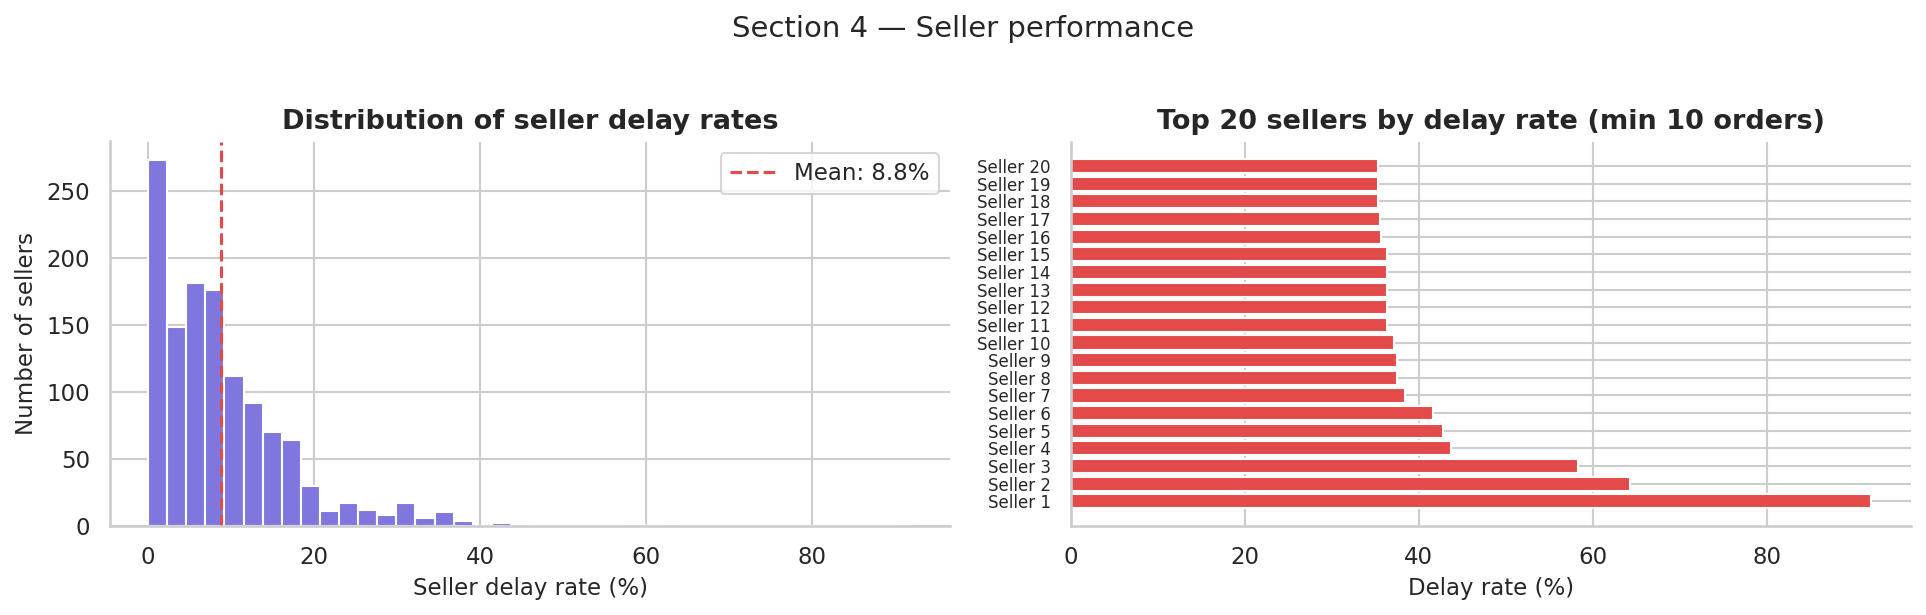

Top 323 sellers (26.1% of sellers) are responsible for 80% of all delays.


In [29]:
# ── 4A. Seller delay rate distribution ───────────────────
items_orders = items.merge(df[["order_id","is_delayed"]], on="order_id", how="inner")

seller_stats = items_orders.groupby("seller_id").agg(
    total_orders=("order_id","nunique"),
    delayed_orders=("is_delayed","sum")
).reset_index()
seller_stats["delay_rate"] = (seller_stats["delayed_orders"]
                               / seller_stats["total_orders"] * 100)
seller_stats = seller_stats[seller_stats["total_orders"] >= 10]  # min volume

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribution of seller delay rates
axes[0].hist(seller_stats["delay_rate"], bins=40,
             color=NEUTRAL_COLOR, edgecolor="white")
axes[0].axvline(seller_stats["delay_rate"].mean(), color=DELAY_COLOR,
                linestyle="--", label=f"Mean: {seller_stats['delay_rate'].mean():.1f}%")
axes[0].set_xlabel("Seller delay rate (%)")
axes[0].set_ylabel("Number of sellers")
axes[0].set_title("Distribution of seller delay rates")
axes[0].legend()

# Top 20 worst sellers by volume-weighted delay rate
top_bad = seller_stats.sort_values("delay_rate", ascending=False).head(20)
axes[1].barh(range(20), top_bad["delay_rate"].values, color=DELAY_COLOR)
axes[1].set_yticks(range(20))
axes[1].set_yticklabels([f"Seller {i+1}" for i in range(20)], fontsize=8)
axes[1].set_xlabel("Delay rate (%)")
axes[1].set_title("Top 20 sellers by delay rate (min 10 orders)")

plt.suptitle("Section 4 — Seller performance", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("eda_04_sellers.png", bbox_inches="tight")
plt.show()

# ── 4B. 80/20 analysis — what share of sellers cause 80% of delays? ──
seller_stats_sorted = seller_stats.sort_values("delayed_orders", ascending=False)
seller_stats_sorted["cumulative_pct"] = (
    seller_stats_sorted["delayed_orders"].cumsum()
    / seller_stats_sorted["delayed_orders"].sum() * 100
)
cutoff = seller_stats_sorted[seller_stats_sorted["cumulative_pct"] <= 80].shape[0]
total  = len(seller_stats_sorted)
print(f"Top {cutoff} sellers ({cutoff/total*100:.1f}% of sellers) "
      f"are responsible for 80% of all delays.")

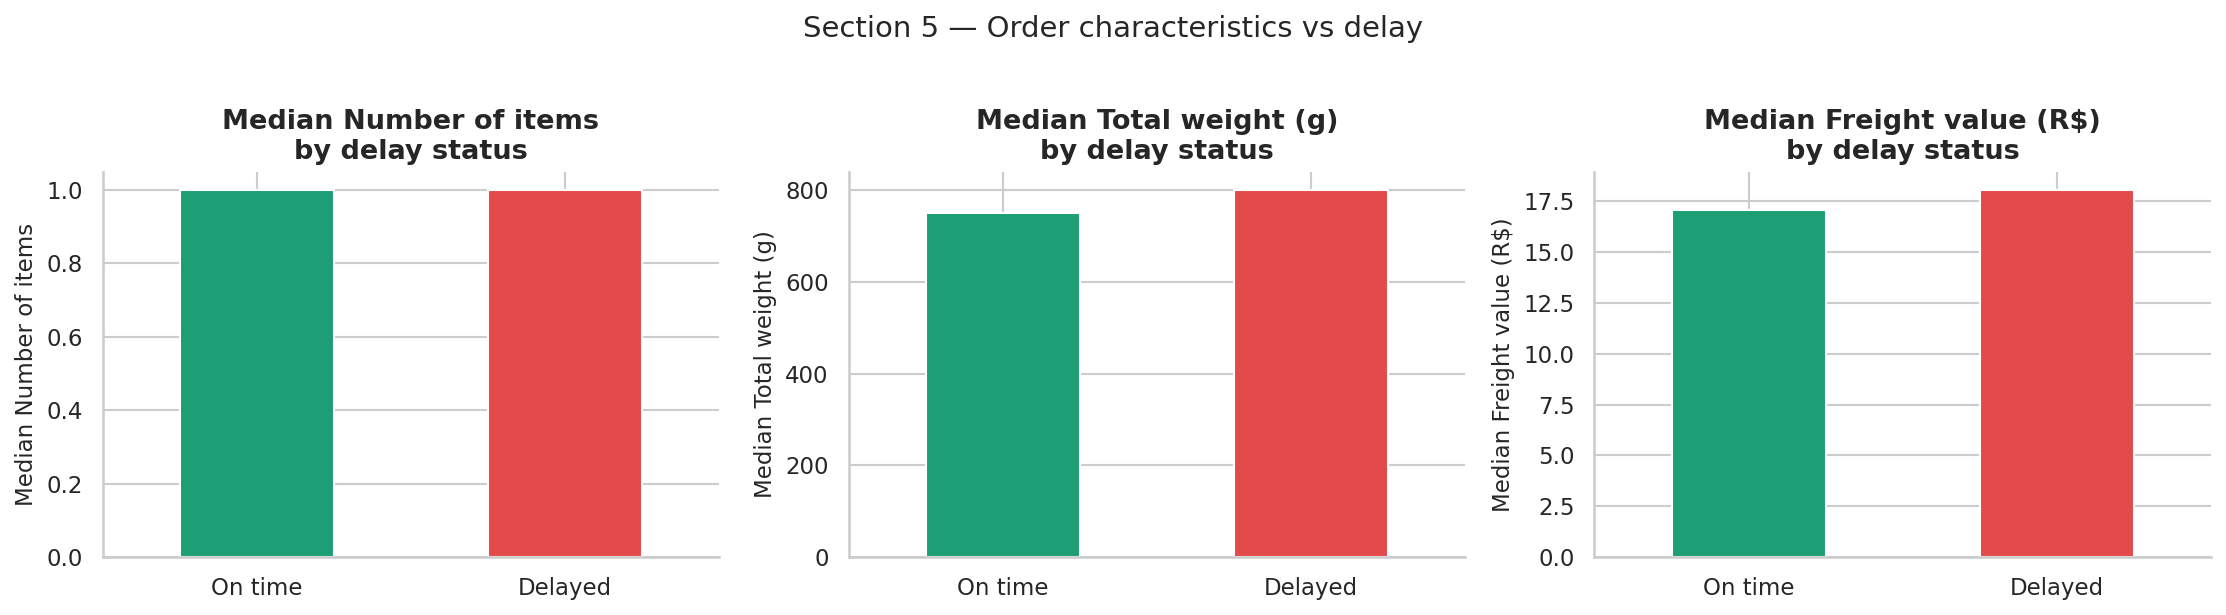

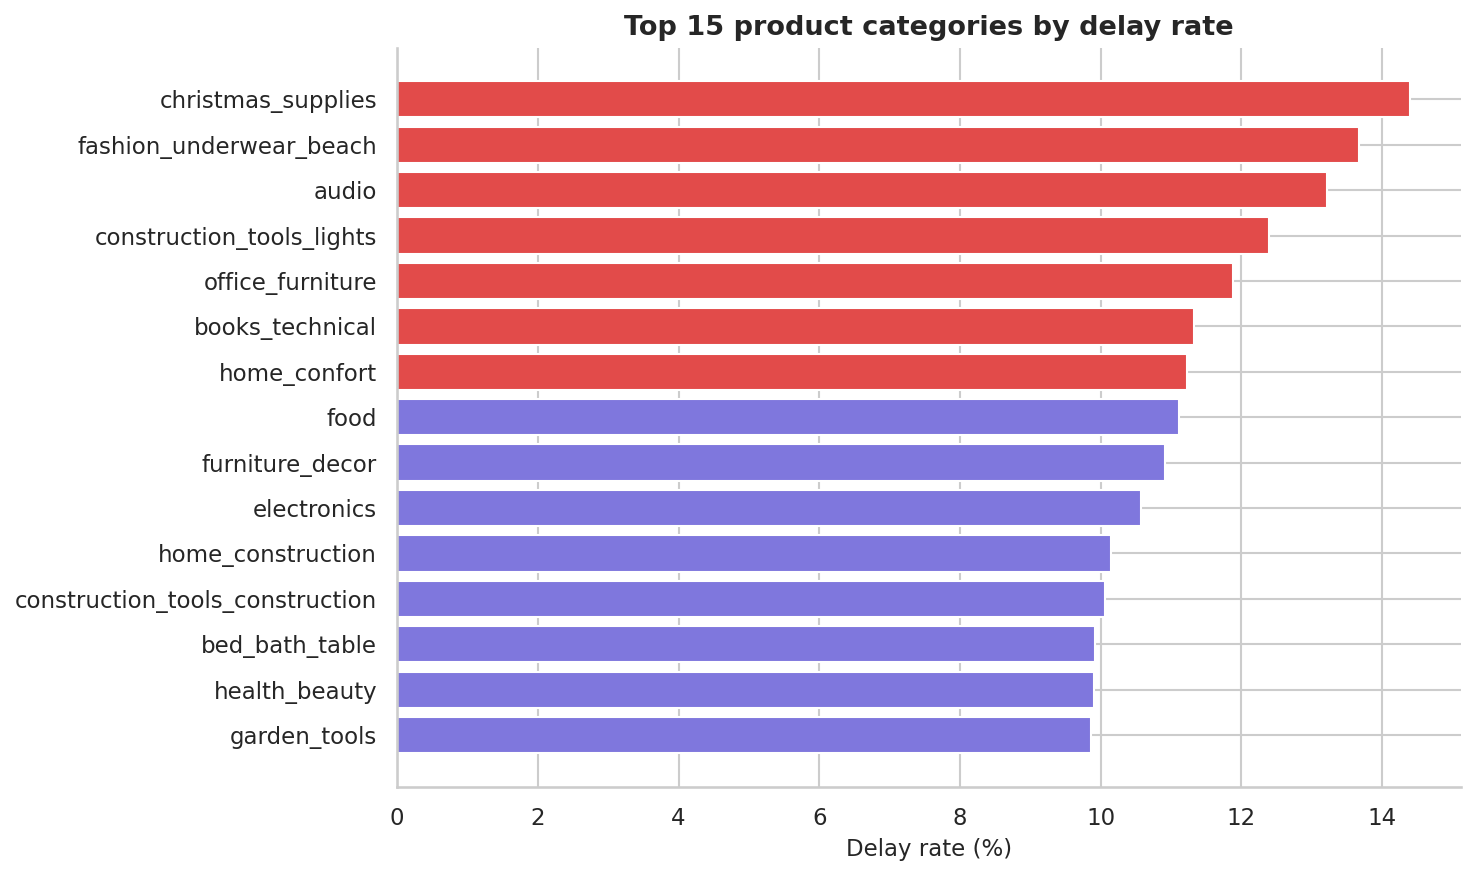

In [30]:
# ── 5A. Order size and weight vs delay ───────────────────
items_agg = items.groupby("order_id").agg(
    total_items=("order_item_id","count"),
    total_price=("price","sum"),
    total_freight=("freight_value","sum")
).reset_index()

# Product weight join
prod_clean = products.merge(cat_trans, on="product_category_name", how="left")
prod_clean["volume_cm3"] = (prod_clean["product_length_cm"]
                             * prod_clean["product_height_cm"]
                             * prod_clean["product_width_cm"])

items_prod = items.merge(prod_clean[["product_id","product_weight_g",
                                      "volume_cm3","product_category_name_english"]],
                          on="product_id", how="left")
weight_agg = items_prod.groupby("order_id").agg(
    total_weight_g=("product_weight_g","sum"),
    total_volume=("volume_cm3","sum")
).reset_index()

df_prod = df.merge(items_agg,   on="order_id", how="left")
df_prod = df_prod.merge(weight_agg, on="order_id", how="left")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, label in zip(axes,
    ["total_items", "total_weight_g", "total_freight"],
    ["Number of items", "Total weight (g)", "Freight value (R$)"]):

    df_prod.groupby("is_delayed")[col].median().plot(
        kind="bar", ax=ax, color=[ON_TIME_COLOR, DELAY_COLOR],
        edgecolor="white", width=0.5)
    ax.set_title(f"Median {label}\nby delay status")
    ax.set_xlabel("")
    ax.set_xticklabels(["On time","Delayed"], rotation=0)
    ax.set_ylabel(f"Median {label}")

plt.suptitle("Section 5 — Order characteristics vs delay", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("eda_05_product.png", bbox_inches="tight")
plt.show()

# ── 5B. Delay rate by product category (top 15) ──────────
items_prod_orders = items_prod.merge(df[["order_id","is_delayed"]],
                                      on="order_id", how="inner")
cat_delay = items_prod_orders.groupby("product_category_name_english").agg(
    total=("order_id","nunique"),
    delayed=("is_delayed","sum")
).reset_index()
cat_delay["delay_rate"] = cat_delay["delayed"] / cat_delay["total"] * 100
cat_delay = cat_delay[cat_delay["total"] > 100].sort_values(
    "delay_rate", ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(cat_delay["product_category_name_english"], cat_delay["delay_rate"],
        color=[DELAY_COLOR if v > cat_delay["delay_rate"].median()
               else NEUTRAL_COLOR for v in cat_delay["delay_rate"]])
ax.set_xlabel("Delay rate (%)")
ax.set_title("Top 15 product categories by delay rate")
plt.tight_layout()
plt.savefig("eda_05b_category.png", bbox_inches="tight")
plt.show()

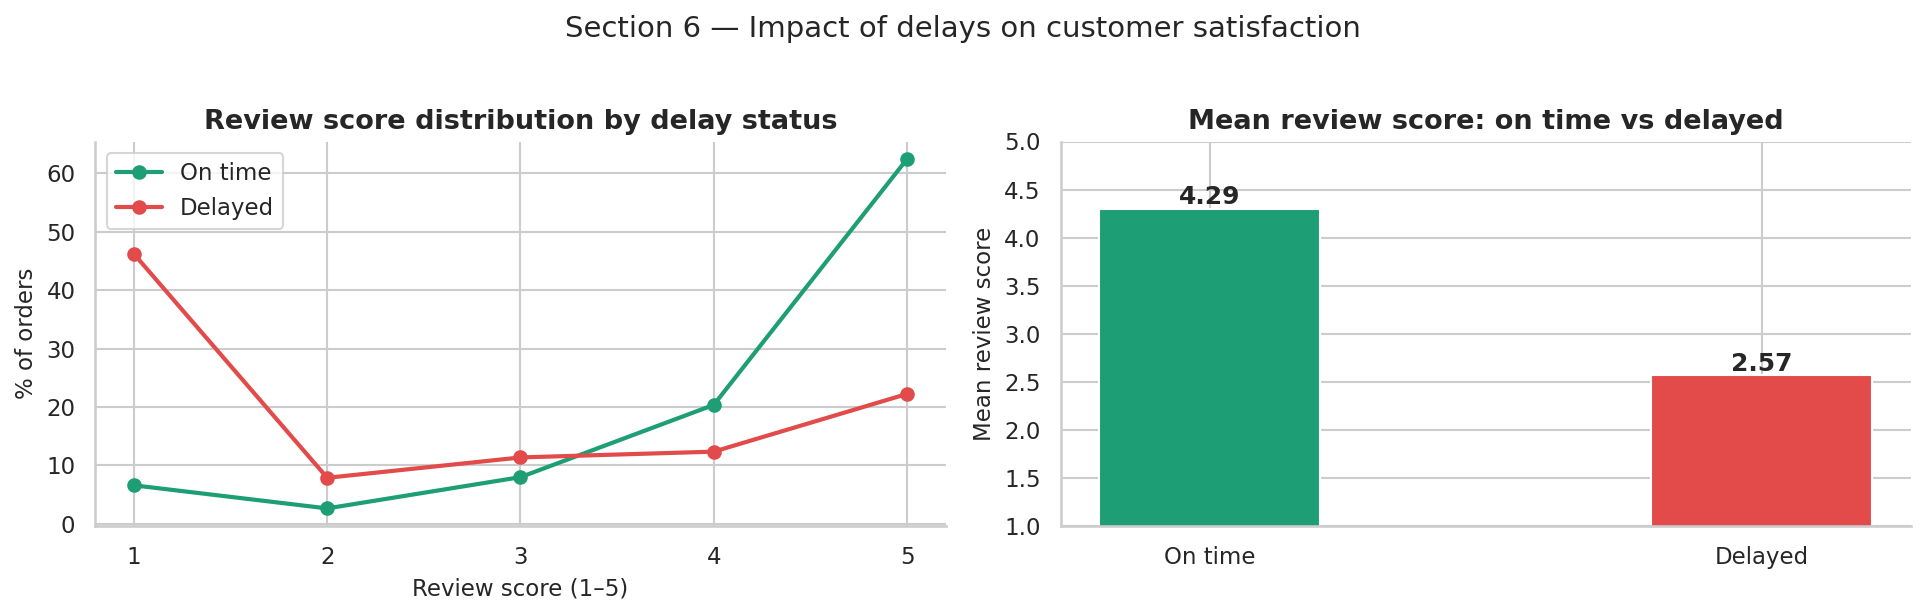

37.9% of all 1-star reviews came from delayed orders.


/tmp/ipykernel_3330/2170923382.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  severity = df_late.groupby(late_bins)["review_score"].mean()


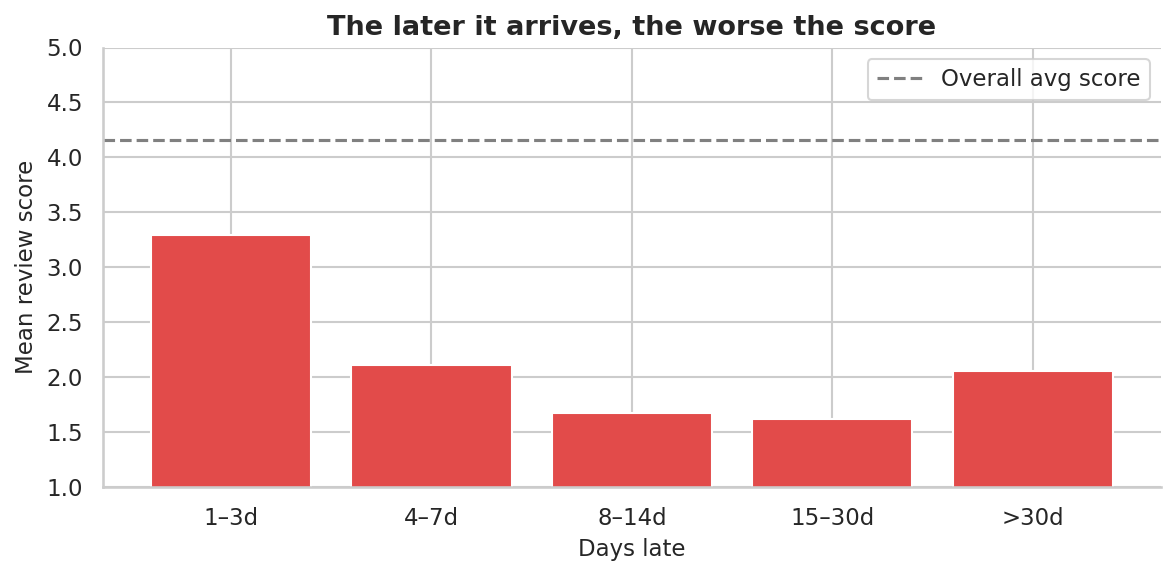

In [31]:
# ── 6A. Review score distribution by delay status ────────
reviews_clean = reviews.drop_duplicates("order_id")
df_rev = df.merge(reviews_clean[["order_id","review_score"]], on="order_id", how="left")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Score distribution split
for score_val, label, color in [(0, "On time", ON_TIME_COLOR),
                                  (1, "Delayed", DELAY_COLOR)]:
    subset = df_rev[df_rev["is_delayed"] == score_val]["review_score"].dropna()
    score_counts = subset.value_counts(normalize=True).sort_index() * 100
    axes[0].plot(score_counts.index, score_counts.values,
                 marker="o", label=label, color=color, linewidth=2)

axes[0].set_xticks([1,2,3,4,5])
axes[0].set_xlabel("Review score (1–5)")
axes[0].set_ylabel("% of orders")
axes[0].set_title("Review score distribution by delay status")
axes[0].legend()

# Mean review score per delay status
mean_scores = df_rev.groupby("is_delayed")["review_score"].mean()
axes[1].bar(["On time","Delayed"], mean_scores.values,
            color=[ON_TIME_COLOR, DELAY_COLOR], width=0.4)
axes[1].set_ylim([1, 5])
axes[1].set_ylabel("Mean review score")
axes[1].set_title("Mean review score: on time vs delayed")
for i, v in enumerate(mean_scores.values):
    axes[1].text(i, v + 0.05, f"{v:.2f}", ha="center", fontweight="bold")

plt.suptitle("Section 6 — Impact of delays on customer satisfaction",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("eda_06_reviews.png", bbox_inches="tight")
plt.show()

# ── 6B. % of 1-star reviews caused by delays ─────────────
one_star = df_rev[df_rev["review_score"] == 1]
pct_delayed_1star = one_star["is_delayed"].mean() * 100
print(f"{pct_delayed_1star:.1f}% of all 1-star reviews came from delayed orders.")

# Delay severity vs review score
df_rev["days_late"] = (
    (df_rev["order_delivered_customer_date"] -
     df_rev["order_estimated_delivery_date"]).dt.days
)
df_late = df_rev[df_rev["days_late"] > 0]
late_bins = pd.cut(df_late["days_late"], bins=[0,3,7,14,30,999],
                   labels=["1–3d","4–7d","8–14d","15–30d",">30d"])
severity = df_late.groupby(late_bins)["review_score"].mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(severity.index.astype(str), severity.values, color=DELAY_COLOR)
ax.set_ylim([1, 5])
ax.axhline(df_rev["review_score"].mean(), linestyle="--",
           color="gray", label="Overall avg score")
ax.set_xlabel("Days late")
ax.set_ylabel("Mean review score")
ax.set_title("The later it arrives, the worse the score")
ax.legend()
plt.tight_layout()
plt.savefig("eda_06b_severity.png", bbox_inches="tight")
plt.show()